- database for gene co-expression: https://coxpresdb.jp/gene_coexpression/?gene_id=7535&dataset=17
- topic modeling: https://github.com/gregversteeg/corex_topic/blob/master/corextopic/example/corex_topic_example.ipynb 

1.	PI3K/AKT/mTOR: Increase
2.	mTORC1: Increase
3.	P53: Increase
4.	TNF-α/NF-κB: Increase
5.	TGF-β: Increase
6.	WNT/β-Catenin: Dysregulated
7.	Oxidative Phosphorylation (OXPHOS): Decrease


### robustness 
- we included only genes that are exressed across all age groups. there could be a scenario where there is high expression of a particular genes for an age group
- normalization technique 
- corr method 
- subsampling 



# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy import stats
import networkx as nx

import sys
import matplotlib.pyplot as plt
import scanpy as sc 
# import decoupler as dc 
# from scipy.stats import pearsonr
import json
import itertools
import warnings
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.preprocessing import minmax_scale
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests


from src.helper import *

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt, quantile_transformation, zscore_transformation
from task_grn_inference.src.process_data.perturbation.normalization.script import normalize_func
from scipy.cluster.hierarchy import linkage



%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

warnings.filterwarnings("ignore")

task_grn_inference_dir = '../task_grn_inference'

par = {
    'input_dir': 'input/',
    'age_groups': ['34-', '35_44', '45_54', '55_64', '65_75']
    }

genesets_dict = get_genesets()
target_genes = np.unique(np.concatenate(list(genesets_dict.values())))

# Create a DataFrame for pathway annotations
pathway_assignments = []
for pathway, genes in genesets_dict.items():
    for gene in genes:
        pathway_assignments.append((gene, pathway))

pathway_df = pd.DataFrame(pathway_assignments, columns=['gene', 'pathway']).set_index('gene')


df = pd.read_csv('https://www.tau.ac.il/~elieis/HKG/HK_genes.txt', sep=' ', header=None)
housekeeping_genes = set(df.loc[:, 0])

# Correlation analysis

In [5]:
if False:
    import subprocess
    from itertools import product

    # Example usage
    normalize_options = ['sla']  # Replace with actual normalization options
    corr_method_options = ['pearson', 'spearman']  # Replace with actual correlation methods
    denoise_options = [True, False]  # Boolean argument options

    i_job = 0
    for normalize, corr_method, denoise in product(normalize_options, corr_method_options, denoise_options):
        # Prepare the sbatch command with arguments
        if True:
            sbatch_command = [
                "sbatch",
                f"--job-name=coexp_analysis_{i_job}",
                "--output=logs/output_%j.log",
                "--error=logs/error_%j.log",
                "--time=02:00:00",
                "--cpus-per-task=4",
                "--mem=250G",
                "--partition=cpu",
                f"scripts/sbatch/corr_analysis.sh",
                f"{normalize}",
                f"{corr_method}",
            ]
        else:
            sbatch_command = [
                "bash",
                f"scripts/sbatch/corr_analysis.sh",
                f"{normalize}",
                f"{corr_method}",
            ]
            
        if denoise:
            sbatch_command += ['denoise']
            
        if os.path.exists(f'output/links_pvalues_vs_34_{normalize}_{corr_method}_{denoise}.csv'):
            continue
        # Submit the job
        print(f"Submitting job with normalize={normalize}, corr_method={corr_method}, denoise={denoise}")
        subprocess.run(sbatch_command)
        i_job+=1

Submitting job with normalize=sla, corr_method=pearson, denoise=True
Submitted batch job 7797534
Submitting job with normalize=sla, corr_method=pearson, denoise=False
Submitted batch job 7797535
Submitting job with normalize=sla, corr_method=spearman, denoise=True
Submitted batch job 7797536
Submitting job with normalize=sla, corr_method=spearman, denoise=False
Submitted batch job 7797537


# PCA analysis across ages

In [2]:
!ls output

coexp_adata_sla_pearson_False.h5ad   links_pvalues_vs_34_sla_pearson_False.csv
coexp_adata_sla_pearson_True.h5ad    links_pvalues_vs_34_sla_pearson_True.csv
coexp_adata_sla_spearman_False.h5ad  links_pvalues_vs_34_sla_spearman_False.csv
coexp_adata_sla_spearman_True.h5ad   links_pvalues_vs_34_sla_spearman_True.csv
data				     repo
figs				     repo_2


In [12]:
if True: 
    coexp_adata = ad.read_h5ad('output/coexp_adata_sla_spearman_False.h5ad')
    coexp_adata.obs.age_group = coexp_adata.obs.age_group.replace('-34', '34-')
    coexp_adata.obs.age_group = coexp_adata.obs.age_group.astype('str').astype('category')
    print(coexp_adata)

    # - keep only that are present in all 
    mask_zeros = (coexp_adata.X==0).any(axis=0)
    coexp_adata = coexp_adata[:, ~mask_zeros]
    print(coexp_adata)
    print(coexp_adata.obs.nunique())
    # - make a df 
    coexp_df = pd.DataFrame(coexp_adata.X, columns=coexp_adata.var_names, index=pd.MultiIndex.from_frame(coexp_adata.obs, names=coexp_adata.obs.columns))

    coexp_long_df = coexp_df.reset_index(level=['batch_group', 'age_group', 'age_donor']).melt(id_vars=['batch_group', 'age_group', 'age_donor'], var_name='link', value_name='weight')
    coexp_long_df.head()

    if True: # testing group difference for different pcs
        sc.pp.pca(coexp_adata)

        data_store = []
        for pca_i in [0, 1, 2, 4, 5, 6]:
            for age_group in coexp_adata.obs.age_group.unique():
                if age_group == '34-':
                    continue 
                mask_control = coexp_adata.obs.age_group == '34-'
                mask_sample = coexp_adata.obs.age_group == age_group
                ctr_pca = coexp_adata[mask_control, :].obsm['X_pca'][:, pca_i]
                ctr_sample = coexp_adata[mask_sample, :].obsm['X_pca'][:, pca_i]

                data = {'age_group':age_group, 'PCA': pca_i, 'pvalue': stats.mannwhitneyu(ctr_pca, ctr_sample)[1]}
                data_store.append(data)
        df_pca_pvalues = pd.DataFrame(data_store)
        df_pca_pvalues['fdr'] = multipletests(df_pca_pvalues['pvalue'], alpha=0.05, method='fdr_bh')[1]

        print(df_pca_pvalues.pivot(index='age_group', columns='PCA', values='fdr'))
if False:
        # -- which links are connected to pca 2
        pc2_loadings = pd.DataFrame({'share':coexp_adata.varm['PCs'][:, 1]}, index= coexp_adata.var_names)
        pc2_loadings = pc2_loadings.sort_values(by='share', ascending=False, key=abs)[:500]
if False:
        # - pca plot
        pca_df = pd.DataFrame(coexp_adata.obsm['X_pca'][:, :6], columns=[f'PC{i+1}' for i in range(6)])

        pca_df['age_group'] = coexp_adata.obs['age_group'].values
        # Create pairplot of all combinations of PC1 to PC6, colored by age_group
        sns.pairplot(pca_df, hue='age_group', palette=colors_blind)  # You can choose any palette you prefer
        plt.suptitle("Pairwise PC1 to PC6 Combinations", y=1.02)
        plt.show()

        # - umap
        coexp_adata.obs[['age','donor_id','sample']] = coexp_adata.obs.age_donor.str.split('_', expand=True)
        # Compute UMAP after PCA
        sc.pp.neighbors(coexp_adata, n_pcs=10)
        sc.tl.umap(coexp_adata)

        # Plot UMAP
        sc.pl.umap(coexp_adata, color=['age_group', 'batch_group'])  # or use any category in `obs` 

AnnData object with n_obs × n_vars = 240 × 380522
    obs: 'age_group', 'batch_group', 'age_donor', 'age', 'cell_count'
View of AnnData object with n_obs × n_vars = 240 × 2527
    obs: 'age_group', 'batch_group', 'age_donor', 'age', 'cell_count'
age_group        5
batch_group      2
age_donor      240
age             49
cell_count      42
dtype: int64
PCA               0         1         2         4         5         6
age_group                                                            
35_44      0.660512  0.008811  0.329033  0.117798  0.045051  0.882684
45_54      0.412191  0.001857  0.882684  0.045051  0.016617  0.794840
55_64      0.362514  0.050668  0.660512  0.017770  0.001584  0.639017
65_75      0.117798  0.001584  0.053228  0.017770  0.091920  0.117798


In [15]:
if False: # headmap association of loadings to pcs
    # lets plot heatmap
    df = pc2_loadings.reset_index()
    df['weight'] = df.share

    g_g_matrix = link_to_matrix(df)
    heatmap_pathways(g_g_matrix, pathway_df)

# Geneset specific distribution

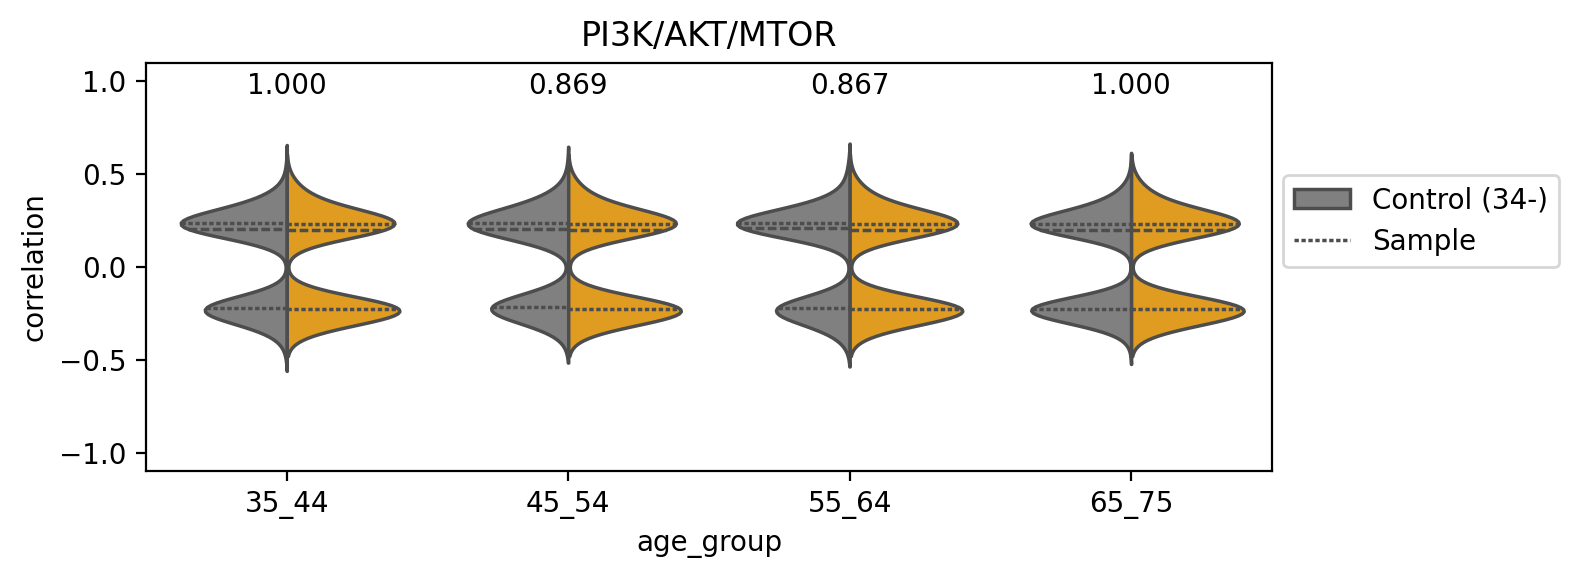

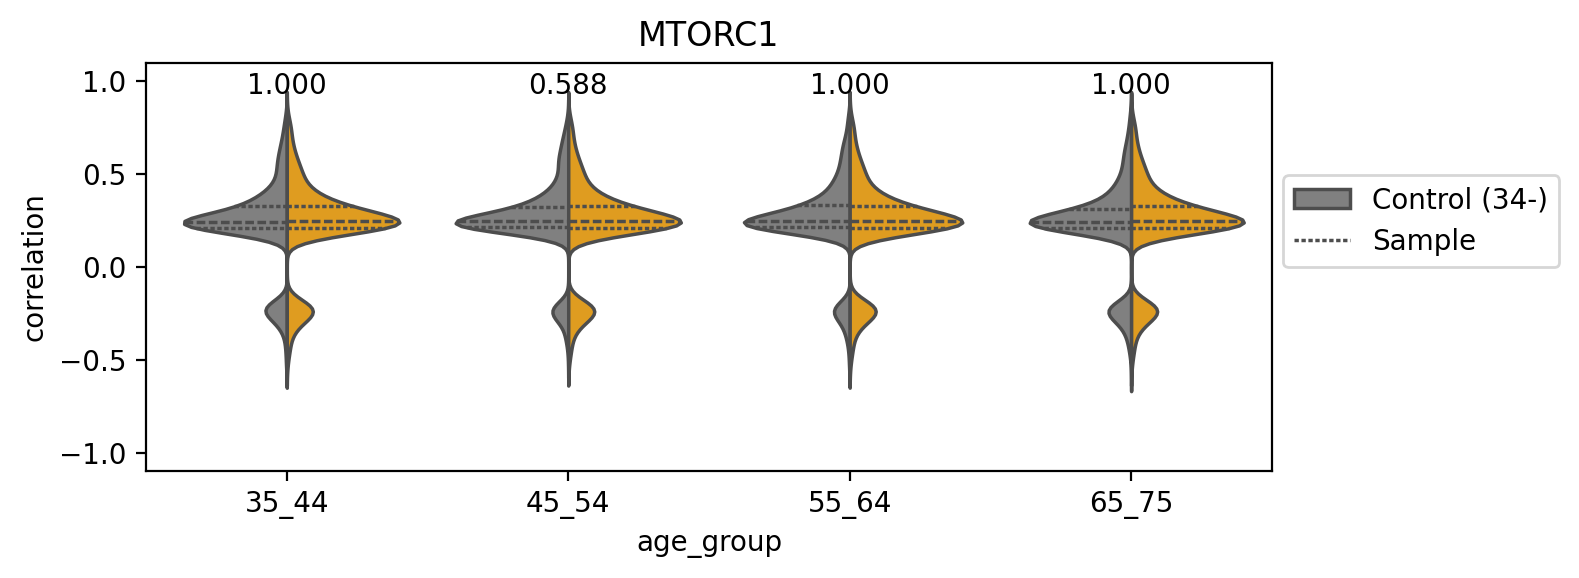

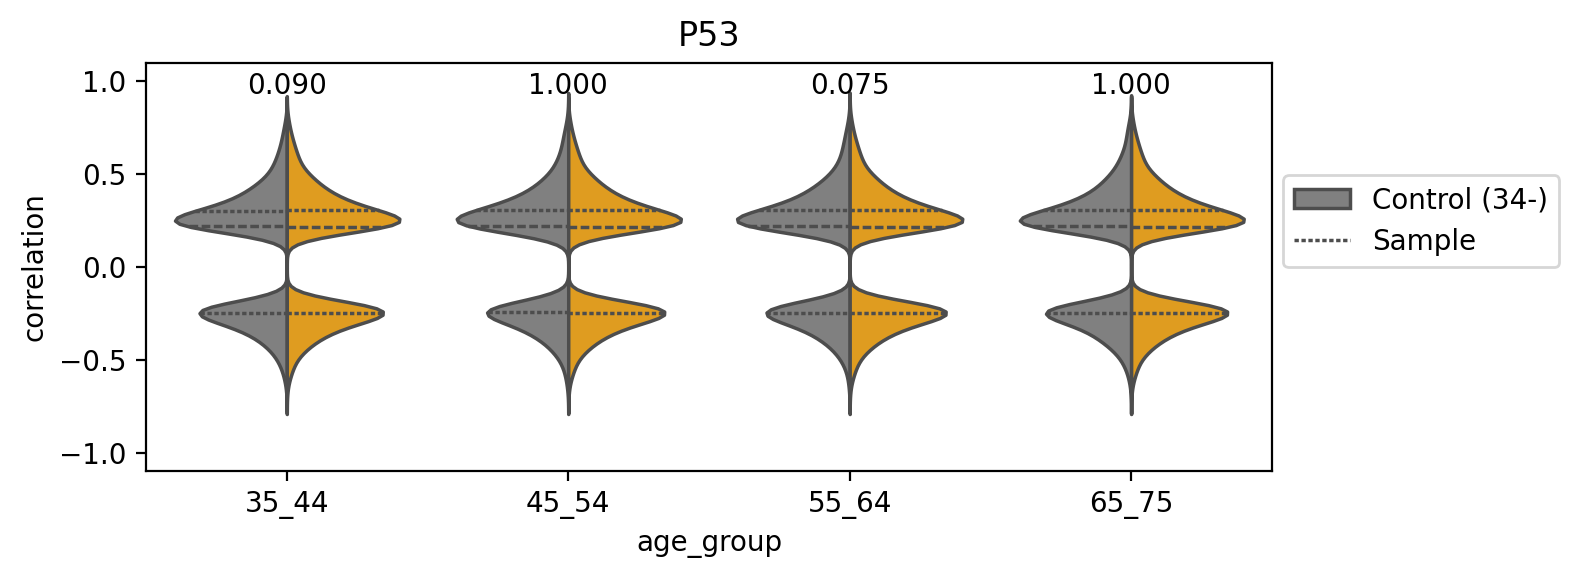

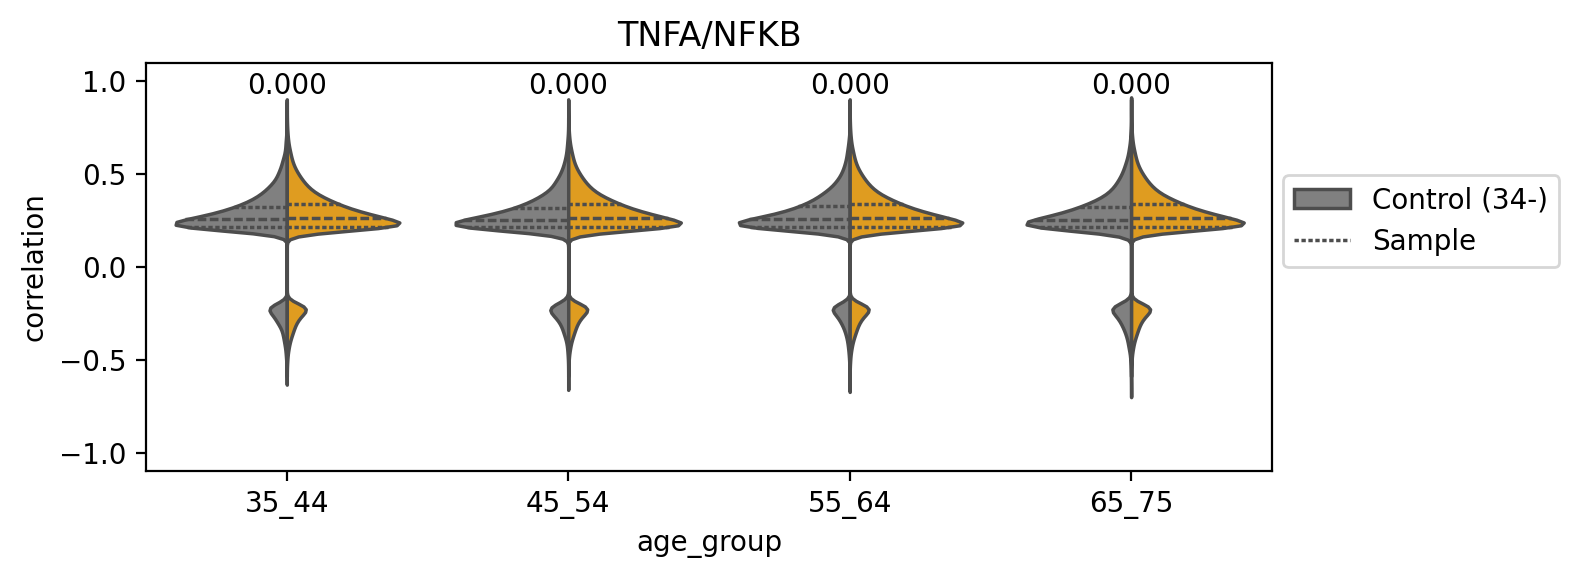

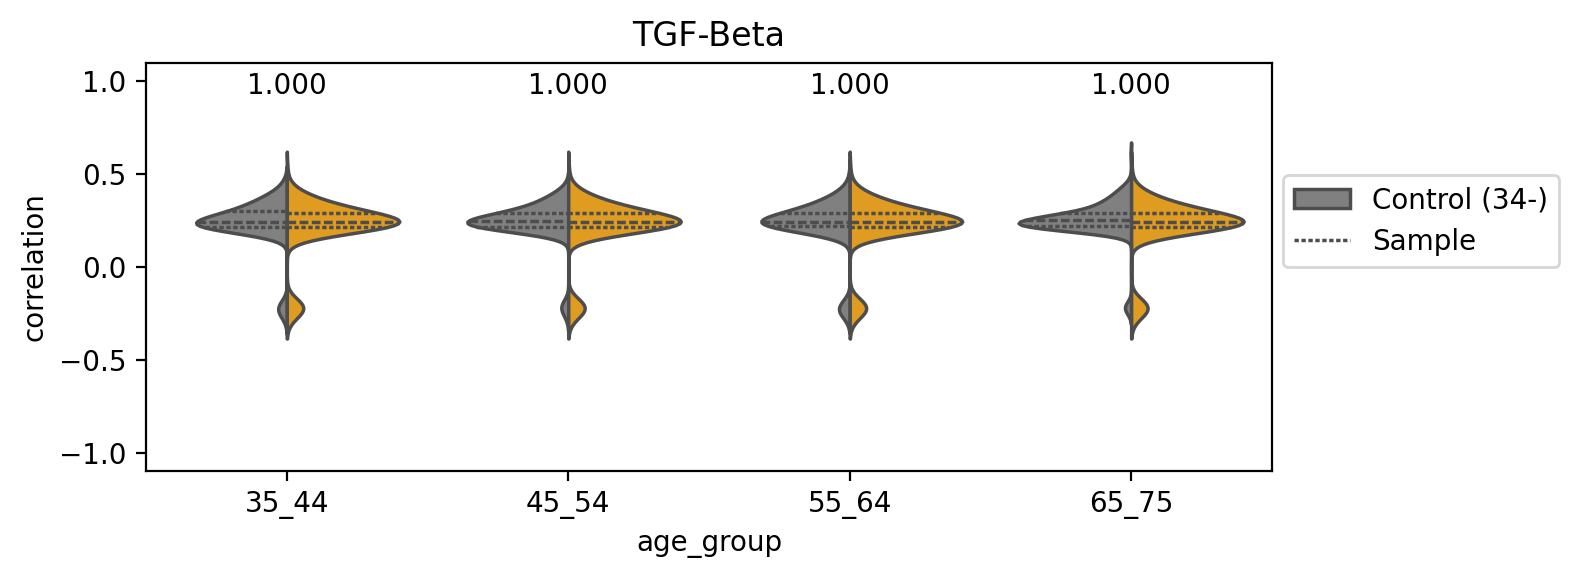

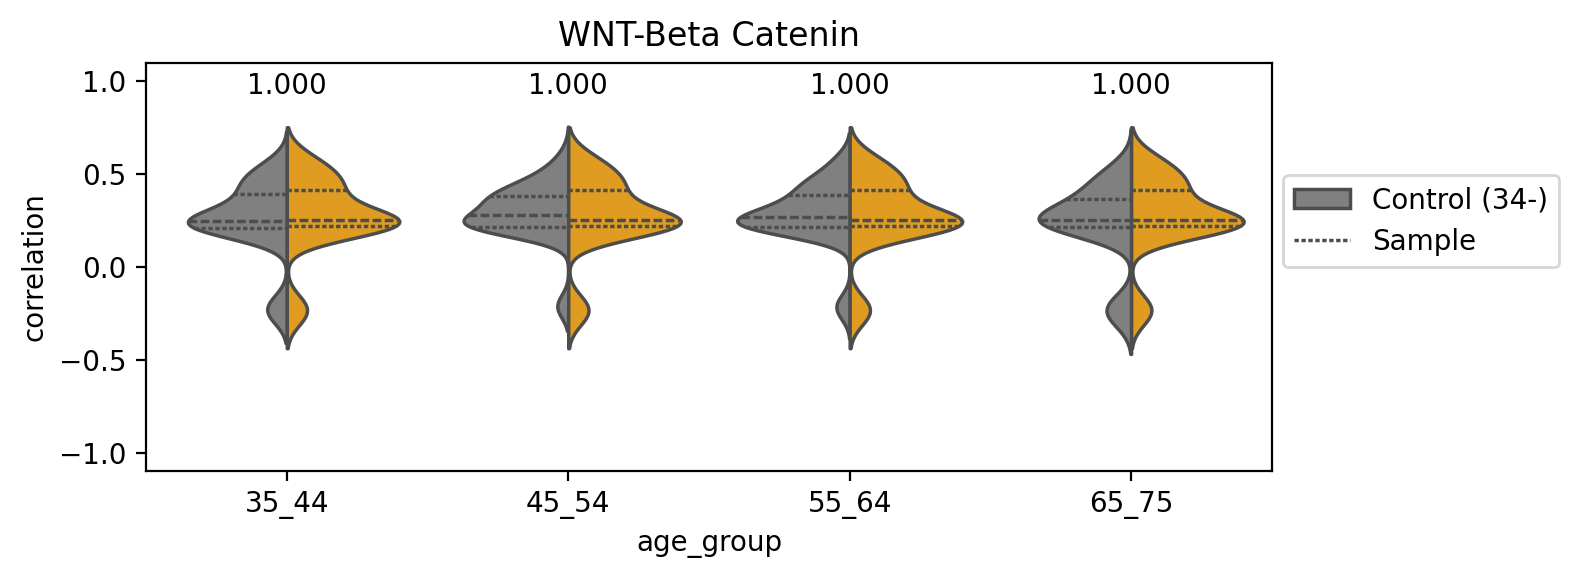

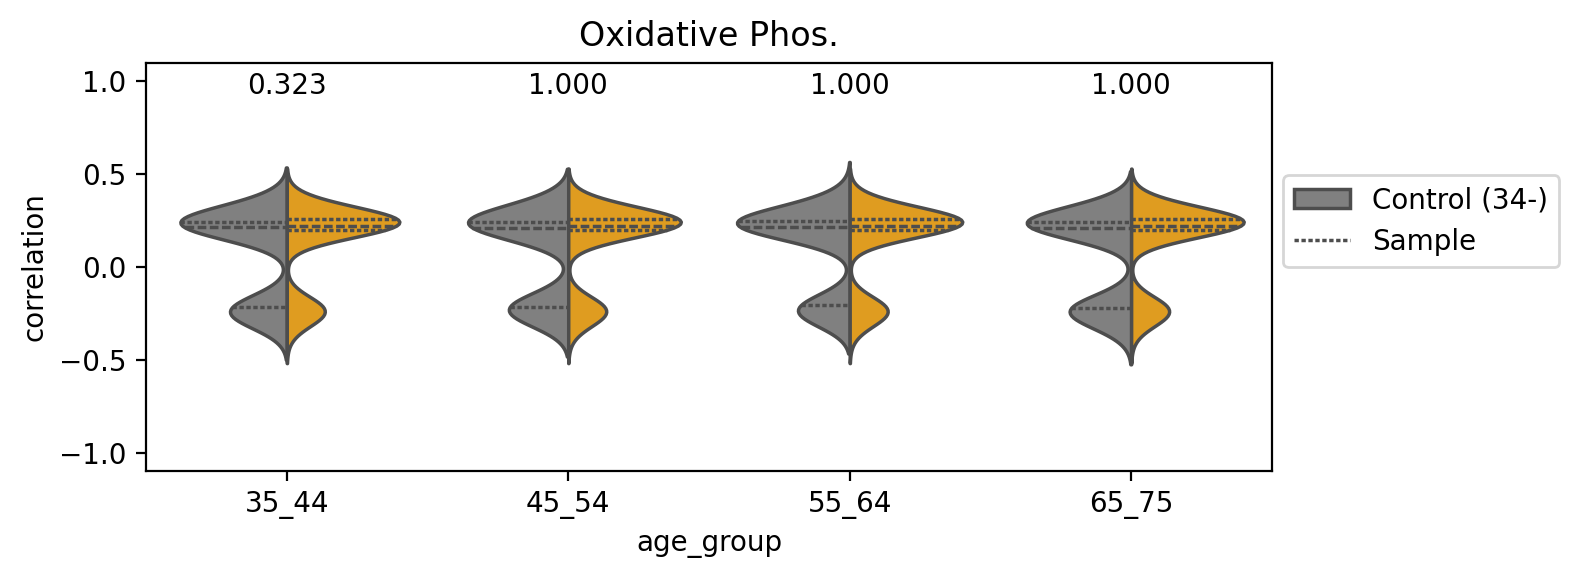

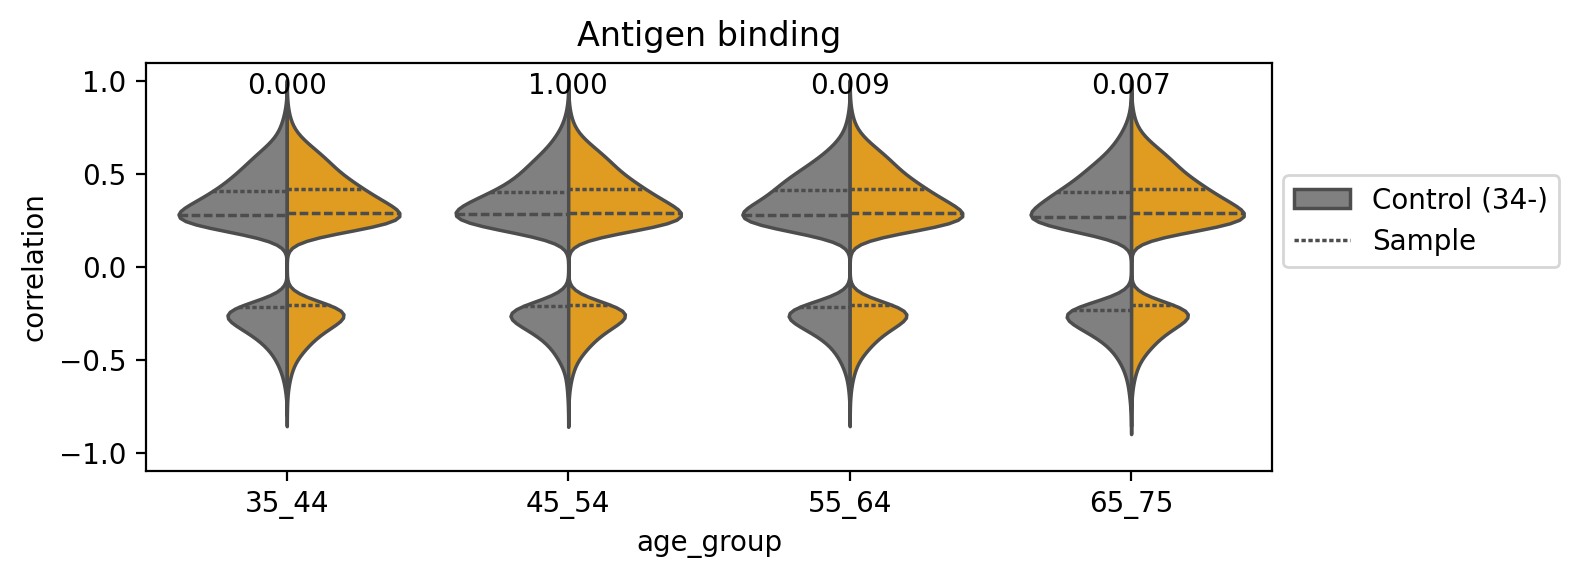

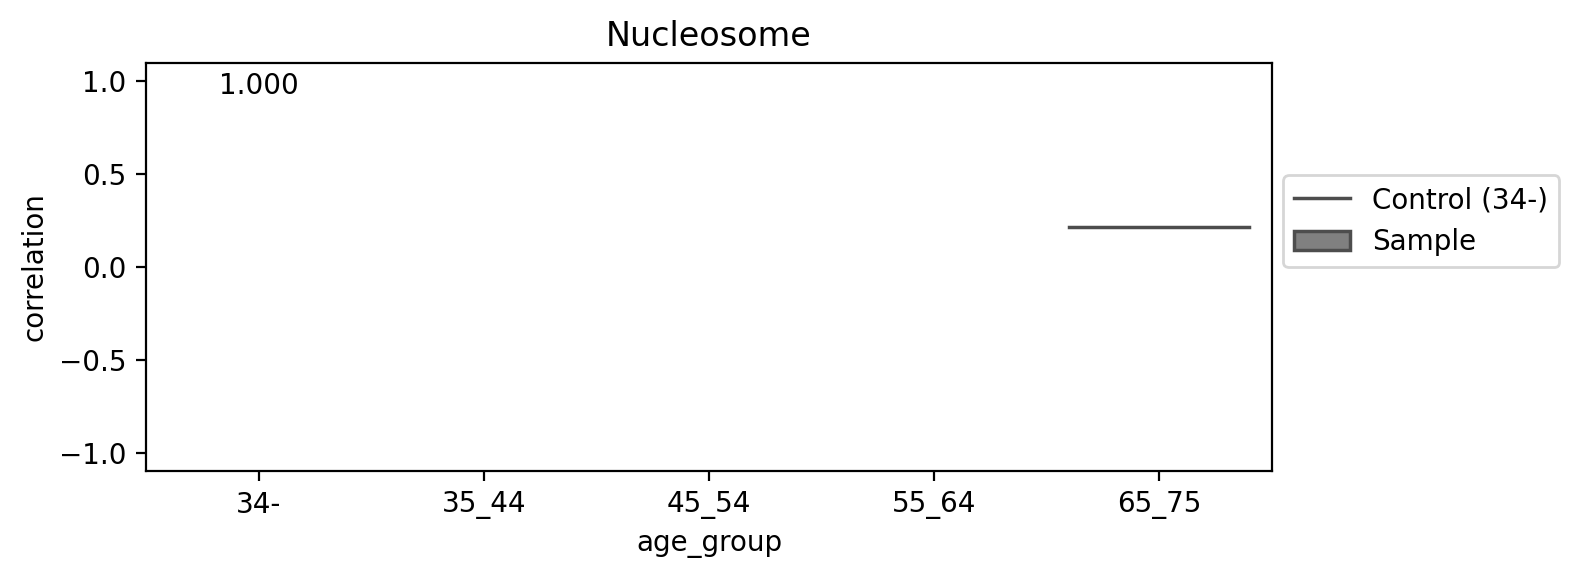

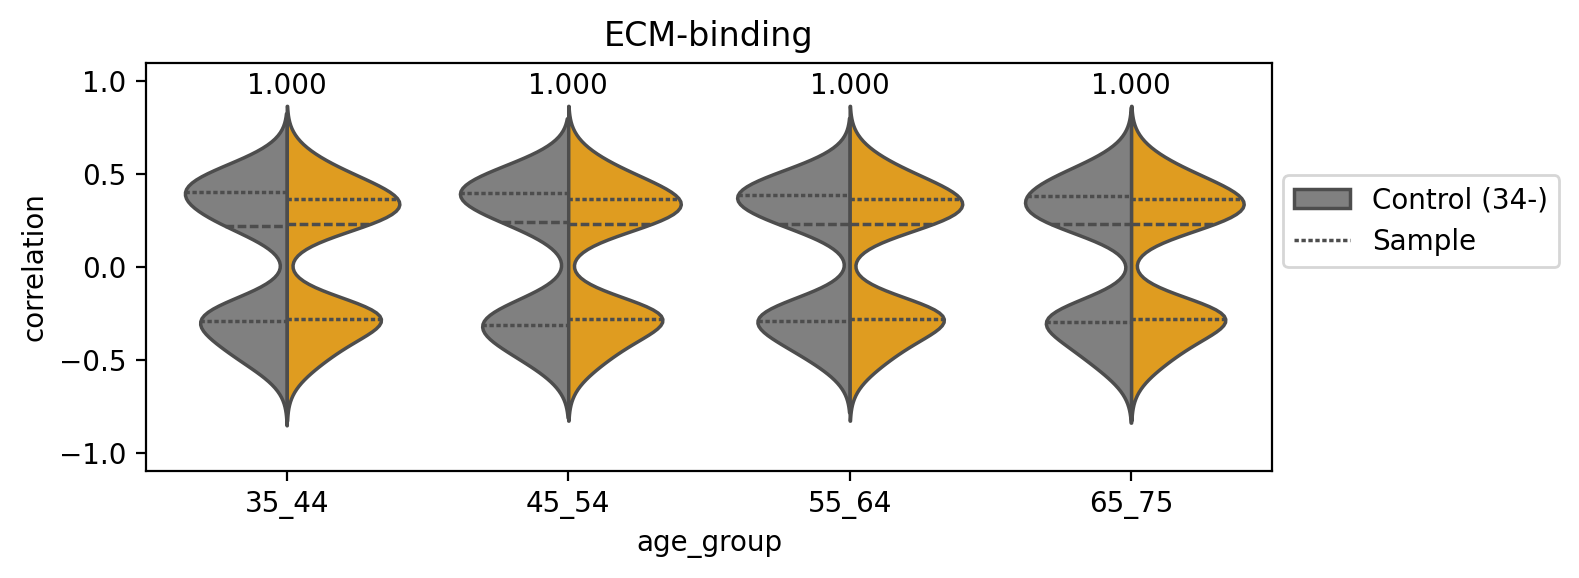

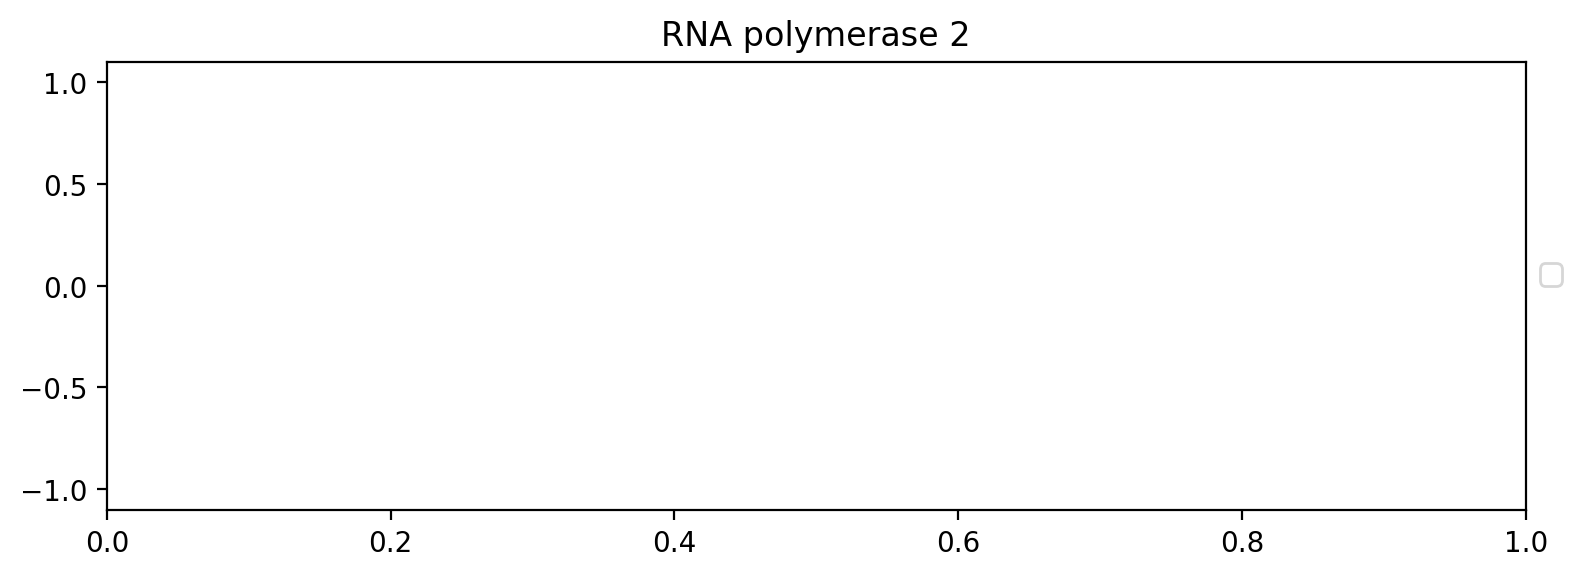

In [81]:
if True: # violin plot for each geneset. p values are calculcated per group
    import seaborn as sns
    import pandas as pd
    import scipy.stats as stats
    
    coexp_adata = ad.read_h5ad('output/coexp_adata_sla_spearman_False.h5ad')

    n_tests = (len(genesets_dict))*4 # to be used for corection
    def do_violin(adata, ax):
        # Prepare correlation data
        corr_df = pd.DataFrame(adata.X, columns=adata.var_names)
        corr_df['age_group'] = adata.obs['age_group'].values
        corr_long = corr_df.melt(id_vars=['age_group'], var_name='link', value_name='correlation')
        corr_long = corr_long[corr_long['correlation'].abs() > 0.2] # cutt-ff on corr
        corr_long = corr_long[corr_long['correlation'] != 0]

        # Separate `34-` and other groups
        corr_long['is_reference'] = corr_long['age_group'] == '34-'
        
        p_values = {}
        reference_group = corr_long[corr_long['is_reference'] == True]

        # Perform Mann-Whitney U test for each other age group vs. '34-'
        for age_group in corr_long['age_group'].unique():
            if age_group == '34-':
                continue 
            target_group = corr_long[(corr_long['age_group'] == age_group)]
            u_stat, p_value = stats.mannwhitneyu(reference_group['correlation'], target_group['correlation'])
            ad_p_value = p_value*n_tests
            p_values[age_group] = min([1, ad_p_value])

            reference_group_c = reference_group.copy()
            reference_group_c['age_group'] = age_group

            corr_long = pd.concat([corr_long, reference_group_c], axis=0)
        corr_long = corr_long[corr_long.age_group!='34-']
        corr_long.age_group = corr_long.age_group.astype('category')
        # Plot side-by-side violin plots
        sns.violinplot(
            x='age_group', y='correlation', hue='is_reference',
            data=corr_long, ax=ax, split=True, inner='quart', palette={True: "orange", False: "gray"}
        )
        

        # # Set limits and add p-values
        ax.set_ylim([-1.1, 1.1])
        for i, age_group in enumerate(p_values.keys()):
            ax.text(i, 0.9, f'{p_values[age_group]:.3f}', ha='center', va='bottom', color='black')

        ax.legend(labels=["Control (34-)", "Sample"], loc=(1.01,.5))
        
    for i , name in enumerate(genesets_dict.keys()):
    # for i , name in enumerate(['RNA polymerase 2']):
        geneset = genesets_dict[name]
        fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    
        geneset_links = ['_'.join(sorted(combination)) for combination in list(itertools.combinations(geneset,2))]
        coexp_adata_g = coexp_adata[:, coexp_adata.var_names.isin(geneset_links)]
        do_violin(coexp_adata_g, ax)

        ax.set_title(f'{name}')

        plt.tight_layout()        

# Edge: sig versus 34-

In [53]:
# - sig links across models
contrast_results_dict = {
    'sla_pearson_False': pd.read_csv('output/links_pvalues_vs_34_sla_pearson_False.csv', index_col=0),
    # 'sla_pearson_True': pd.read_csv('output/links_pvalues_vs_34_sla_pearson_True.csv', index_col=0),
    'sla_spearman_False': pd.read_csv('output/links_pvalues_vs_34_sla_spearman_False.csv', index_col=0),
    # 'sla_spearman_True': pd.read_csv('output/links_pvalues_vs_34_sla_spearman_True.csv', index_col=0),
}

i = 0
for key, df in contrast_results_dict.items():
    
    df['bonferroni'] = multipletests(df['pvalue'], alpha=0.05, method='bonferroni')[1]
    df['fdr'] = multipletests(df['pvalue'], alpha=0.05, method='fdr_bh')[1]
    
    # - add sig column
    df['sig'] = df['fdr']<0.05

    # - filter low rank links
    df = df[df['fdr']<0.05]

    df['model'] = key
    if i == 0:
        sig_results = df
    else:
        sig_results = pd.concat([df, sig_results], axis=0)
    i+=1
sig_results

,link,age_group,pvalue,mean,median,mean_ctr,mean_median,diff_median,diff,bonferroni,fdr,sig,model
21,LCK_RHOB,55_64,0.004178,-0.166678,-0.163619,-0.193380,-0.190048,0.026429,0.026702,1.000000,0.039693,True,sla_spearman_False
22,LCK_RHOB,45_54,0.003043,-0.166975,-0.157858,-0.193380,-0.190048,0.032190,0.026406,1.000000,0.032936,True,sla_spearman_False
25,IL7R_LCK,55_64,0.005294,0.168395,0.171846,0.208100,0.200408,-0.028562,-0.039705,1.000000,0.045530,True,sla_spearman_False
29,CD83_LCK,55_64,0.004656,-0.246812,-0.248452,-0.285189,-0.291517,0.043065,0.038377,1.000000,0.042247,True,sla_spearman_False
30,CD83_LCK,45_54,0.000442,-0.241045,-0.232407,-0.285189,-0.291517,0.059110,0.044144,1.000000,0.012099,True,sla_spearman_False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8101,PRMT2_SAT1,55_64,0.000073,-0.147015,-0.140930,-0.190681,-0.198423,0.057493,0.043667,0.590314,0.004723,True,sla_pearson_False
8102,PRMT2_SAT1,45_54,0.000893,-0.155649,-0.140617,-0.190681,-0.198423,0.057805,0.035032,1.000000,0.014987,True,sla_pearson_False
8112,CFP_SAT1,65_75,0.001855,0.458763,0.461702,0.426863,0.433659,0.028043,0.031900,1.000000,0.021312,True,sla_pearson_False
8116,IL2RG_SAT1,65_75,0.004270,-0.375405,-0.390208,-0.325962,-0.324645,-0.065563,-0.049443,1.000000,0.032851,True,sla_pearson_False


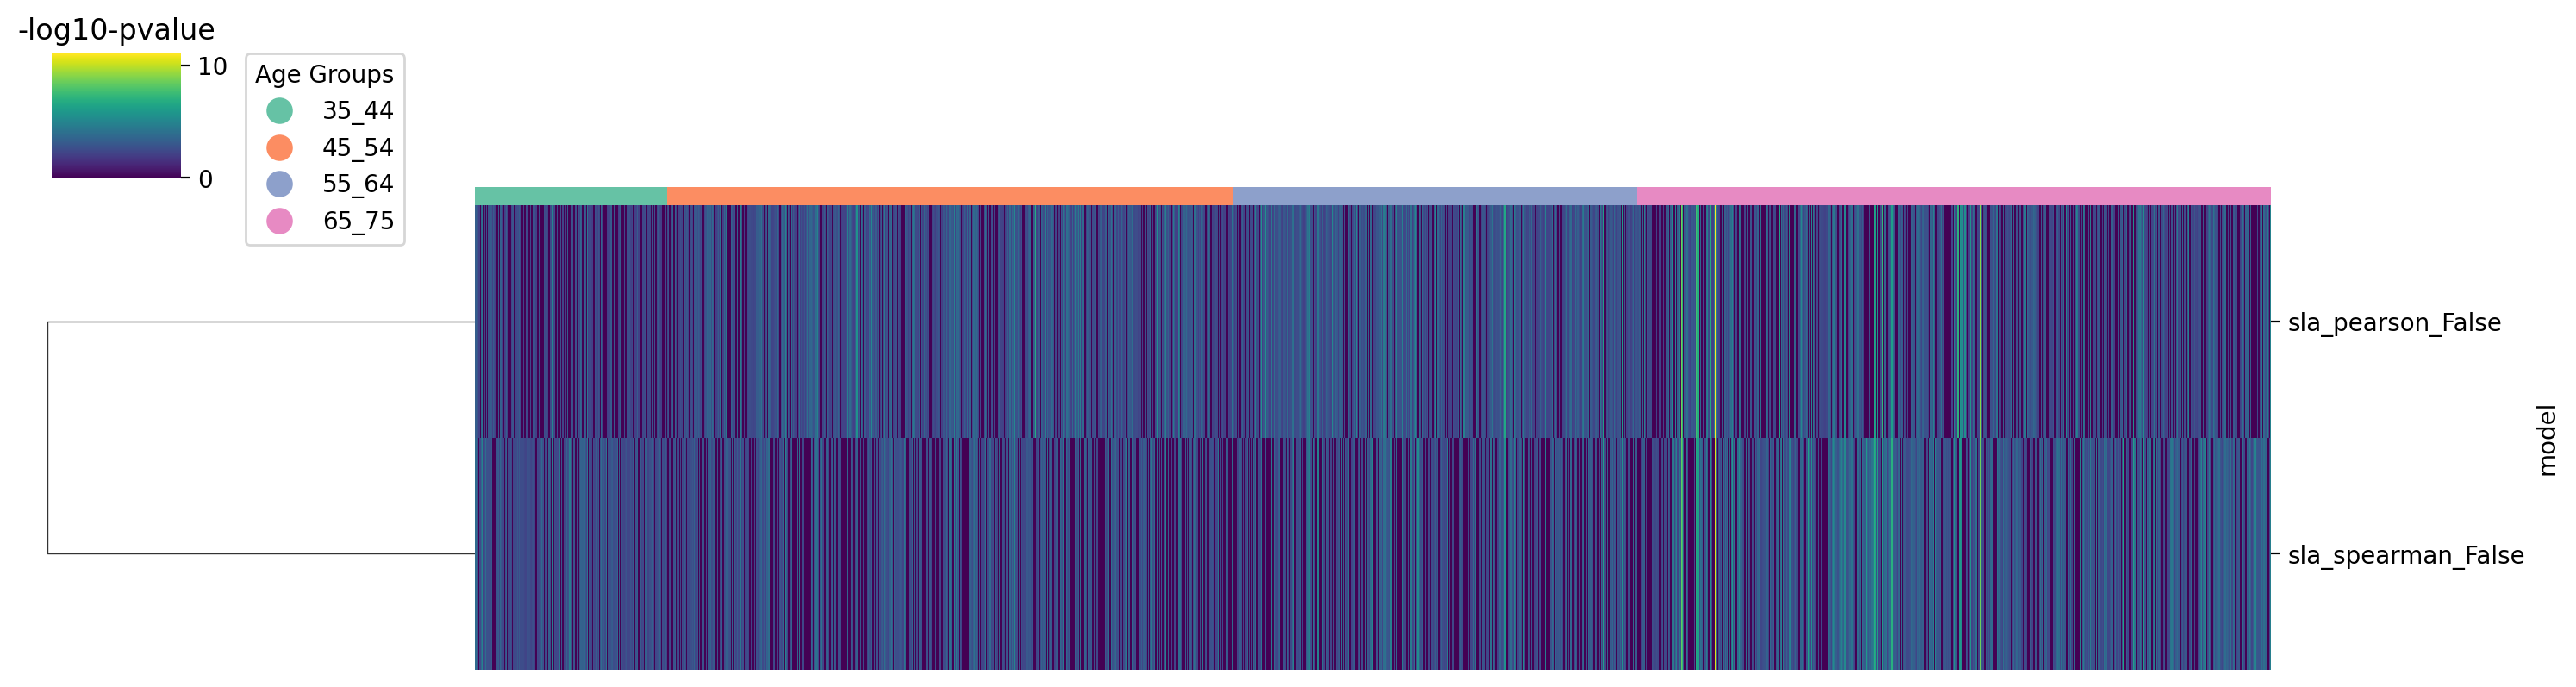

In [71]:
# - plot heatmap for -log10pvalues
sig_results['neglogpvalue'] = -np.log10(sig_results['pvalue'])
sig_results['link_agegroup'] = sig_results['link']+'/'+sig_results['age_group']
sig_results_mat = sig_results.pivot(index='model', columns='link_agegroup', values='neglogpvalue').fillna(0)

age_groups = [name.split('/')[1] for name in sig_results_mat.columns]


# Map unique age groups to colors
unique_groups = np.unique(age_groups)
colors = sns.color_palette("Set2", len(unique_groups))
age_group_colors = dict(zip(unique_groups, colors))

# Reorder the columns of 'df' to group by age group
df = sig_results_mat
age_group_df = pd.DataFrame({'age_group': age_groups, 'column': df.columns})
age_group_df = age_group_df.sort_values('age_group')
ordered_columns = age_group_df['column'].values
ordered_age_groups = age_group_df['age_group'].values

# Reorder the DataFrame and color list
df = df[ordered_columns]
col_colors = [age_group_colors[age] for age in ordered_age_groups]

# Perform hierarchical clustering on rows
linkage_matrix = linkage(df.values, method='ward')

# Plot clustered heatmap with ordered columns and col_colors
g = sns.clustermap(
    df,
    row_linkage=linkage_matrix,
    col_cluster=False,
    cmap='viridis',
    xticklabels=False,
    col_colors=col_colors,
    figsize=(15, 4)
)
colorbar = g.cax  # Access the colorbar axis
colorbar.set_title("-log10-pvalue", fontsize=12)

# Create a legend for age group colors
for age_group, color in age_group_colors.items():
    plt.plot([], [], marker="o", ms=10, ls="", mec=None, color=color, label=age_group)
plt.legend(title="Age Groups", bbox_to_anchor=(1.5, 1), loc='upper left', borderaxespad=0.)
g.ax_heatmap.set_xlabel("")

plt.show()

In [72]:
# - pca analysis
sig_results_mat_a = ad.AnnData(sig_results_mat)
sig_results_mat_a.obs = sig_results_mat_a.obs.reset_index()
sig_results_mat_a.obs['model'] = sig_results_mat_a.obs['model'].astype('category')
sig_results_mat_a.obs['normalize'] = ['APR' if 'apr' in name else 'SLA' for name in sig_results_mat_a.obs['model'] ]
sig_results_mat_a.obs['denoised'] = [True if 'True' in name else False for name in sig_results_mat_a.obs['model']]
sig_results_mat_a

AnnData object with n_obs × n_vars = 2 × 1815
    obs: 'model', 'normalize', 'denoised'

In [59]:
# - common sig links across different methods
n_methods = sig_results.model.nunique()
df = (sig_results.groupby(['link', 'age_group']).apply(lambda df: df['sig'].sum())==n_methods).reset_index(name='sig_common')
sig_results = sig_results.merge(df, on=['link', 'age_group'], how='left')
common_links_df = sig_results[sig_results['sig_common']]

# - add data of each method in the format of method-tag and mean across all
def merge_cols(df):
    # take mean corr
    # df_mean = df.groupby(['link', 'age_group'])['mean'].mean().reset_index(name='mean')
    # pivot to get model specific columns
    df_pivot = df.pivot_table(
        index=['link', 'age_group'],  
        columns='model',              
        values=['mean', 'mean_ctr', 'diff'] 
    )
    df_pivot.columns = ['{}-{}'.format(model, item) for item, model in df_pivot.columns]
    # merge mean with model specific info
    df_pivot = df_pivot.reset_index()
    # df_pivot = df_pivot.merge(df_mean, on=['link', 'age_group'])

    return  df_pivot

common_links_df = merge_cols(common_links_df)

# - add mean corr across all methods
cols_mean = [f'{method}-mean' for method in contrast_results_dict.keys()]
common_links_df['mean'] = common_links_df[cols_mean].mean(axis=1)
common_links_df

,link,age_group,sla_pearson_False-diff,sla_spearman_False-diff,sla_pearson_False-mean,sla_spearman_False-mean,sla_pearson_False-mean_ctr,sla_spearman_False-mean_ctr,mean
0,ACTB_ALDOA,65_75,0.029076,0.031500,0.152737,0.154625,0.123661,0.123125,0.153681
1,ACTB_CASP1,35_44,0.021268,0.024681,0.131056,0.153887,0.109788,0.129207,0.142472
2,ACTB_CFL1,55_64,-0.028325,-0.027399,0.299079,0.306604,0.327405,0.334003,0.302841
3,ACTB_CXCR4,65_75,-0.039766,-0.037423,-0.202407,-0.209667,-0.162641,-0.172244,-0.206037
4,ACTB_LEF1,55_64,0.029858,0.027994,-0.207104,-0.214694,-0.236962,-0.242688,-0.210899
...,...,...,...,...,...,...,...,...,...
827,SPON2_STOM,55_64,-0.041113,-0.036707,0.206568,0.203430,0.247681,0.240138,0.204999
828,SPON2_SYTL2,45_54,-0.020896,-0.023748,0.150298,0.157659,0.171194,0.181407,0.153979
829,TCF7_UQCRB,45_54,-0.024951,-0.028157,0.166524,0.171350,0.191475,0.199507,0.168937
830,TCF7_UQCRB,55_64,-0.038812,-0.040289,0.152663,0.159218,0.191475,0.199507,0.155940


In [60]:
common_links_df.age_group.value_counts()

age_group
65_75    286
45_54    253
55_64    203
35_44     90
Name: count, dtype: int64

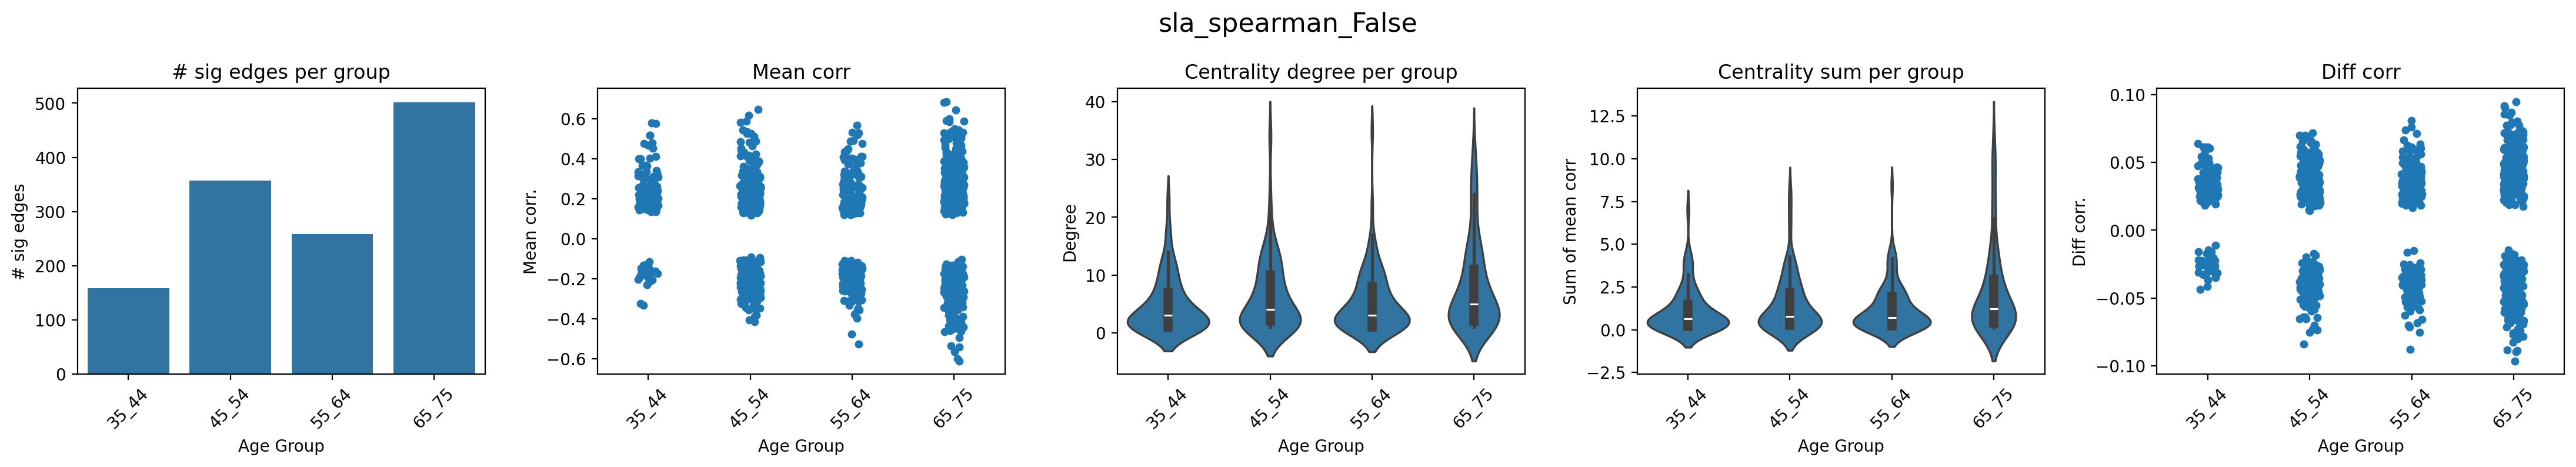

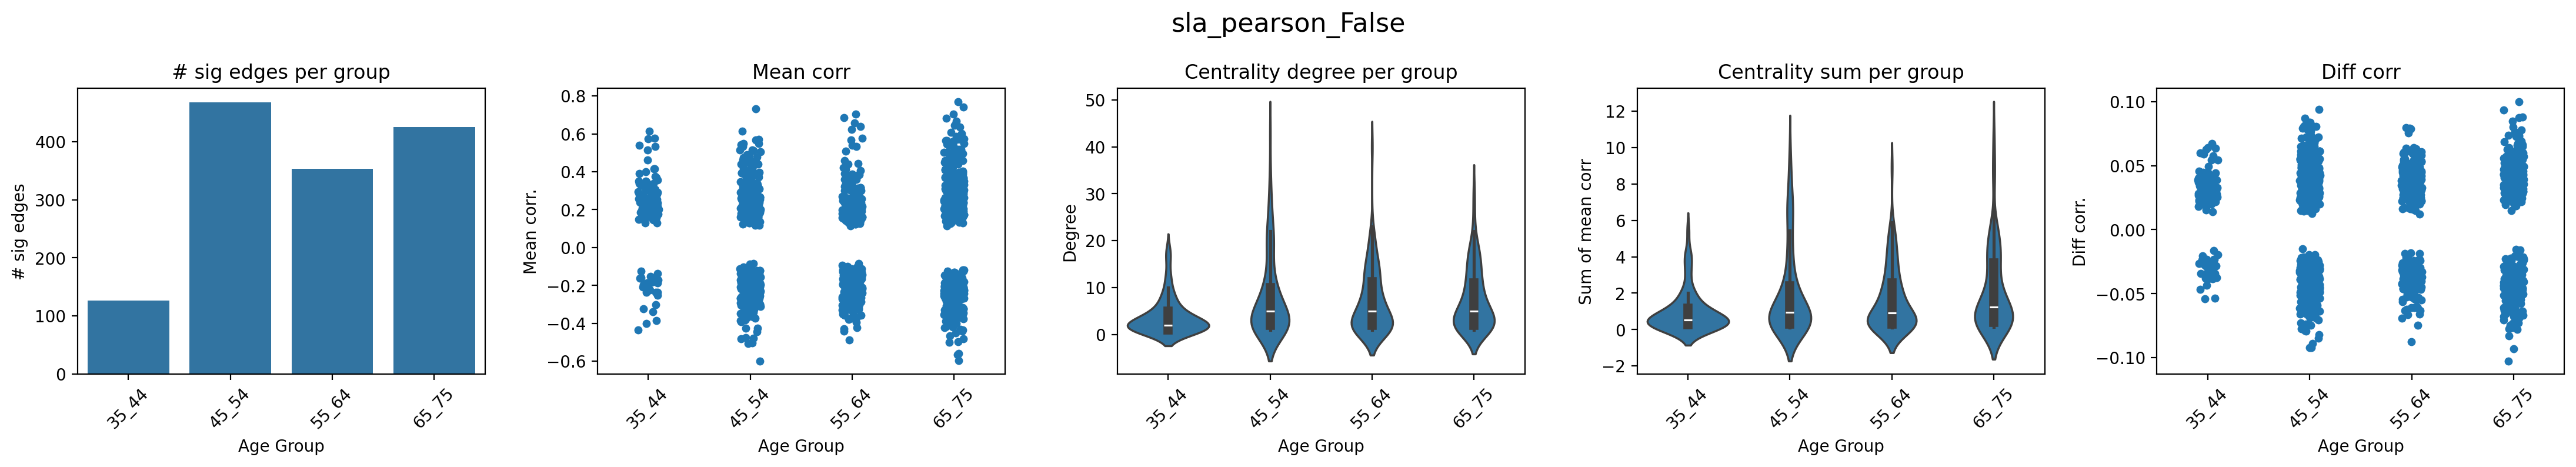

In [61]:
# - plot dist of number of sig links
def plot_exp(groups, suptitle):
    def deg_cent(df):
        df['weight'] = 1
        gg_mat = link_to_matrix(df)
        degree = gg_mat.sum()
        return degree
    def sum_cent(df):
        df['weight'] = df['mean']
        gg_mat = link_to_matrix(df)
        sum_mean = gg_mat.abs().sum()
        return sum_mean

    n_sig_edges = groups.size().reset_index(name='# sig edges')
    mean_corr = groups.apply(lambda df: df['mean']).reset_index(name='mean_corr')
    diff_corr = groups.apply(lambda df: df['diff']).reset_index(name='diff_corr')
    cent_degree = groups.apply(deg_cent).reset_index(name='degree')
    cent_sum = groups.apply(sum_cent).reset_index(name='sum_mean')
    

    # Create subplots
    fig, axes = plt.subplots(1, 5, figsize=(22, 4), gridspec_kw={'width_ratios':[1, 1, 1, 1, 1]})

    # Plot # of edges
    sns.barplot(data=n_sig_edges, x='age_group', y='# sig edges',ax=axes[0])
    axes[0].set_title('# sig edges per group')
    axes[0].set_xlabel('Age Group')
    axes[0].set_ylabel('# sig edges')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot mean corr for each group
    ax = axes[1]
    sns.stripplot(data=mean_corr, x='age_group', y='mean_corr',ax=ax)
    ax.set_title('Mean corr')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Mean corr.')
    ax.tick_params(axis='x', rotation=45)

    # Plot diff corr for each group
    ax = axes[4]
    sns.stripplot(data=diff_corr, x='age_group', y='diff_corr',ax=ax)
    ax.set_title('Diff corr')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Diff corr.')
    ax.tick_params(axis='x', rotation=45)


    # Plot distribution of centrality degree
    ax = axes[2]
    sns.violinplot(data=cent_degree, x='age_group', y='degree',ax=ax)
    ax.set_title('Centrality degree per group')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Degree')
    ax.tick_params(axis='x', rotation=45)

    # Plot distribution of centrality sum
    ax = axes[3]
    sns.violinplot(data=cent_sum, x='age_group', y='sum_mean',ax=ax)
    ax.set_title('Centrality sum per group')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Sum of mean corr')
    ax.tick_params(axis='x', rotation=45)


    fig.suptitle(suptitle, fontsize=16)

    # Adjust layout
    plt.tight_layout()
    
for model in sig_results.model.unique():
    df = sig_results[sig_results.model==model]
    groups = df.groupby('age_group')
    plot_exp(groups, model)
    

['sla_pearson_False', 'sla_spearman_False']
['sla_spearman_False', 'sla_pearson_False']


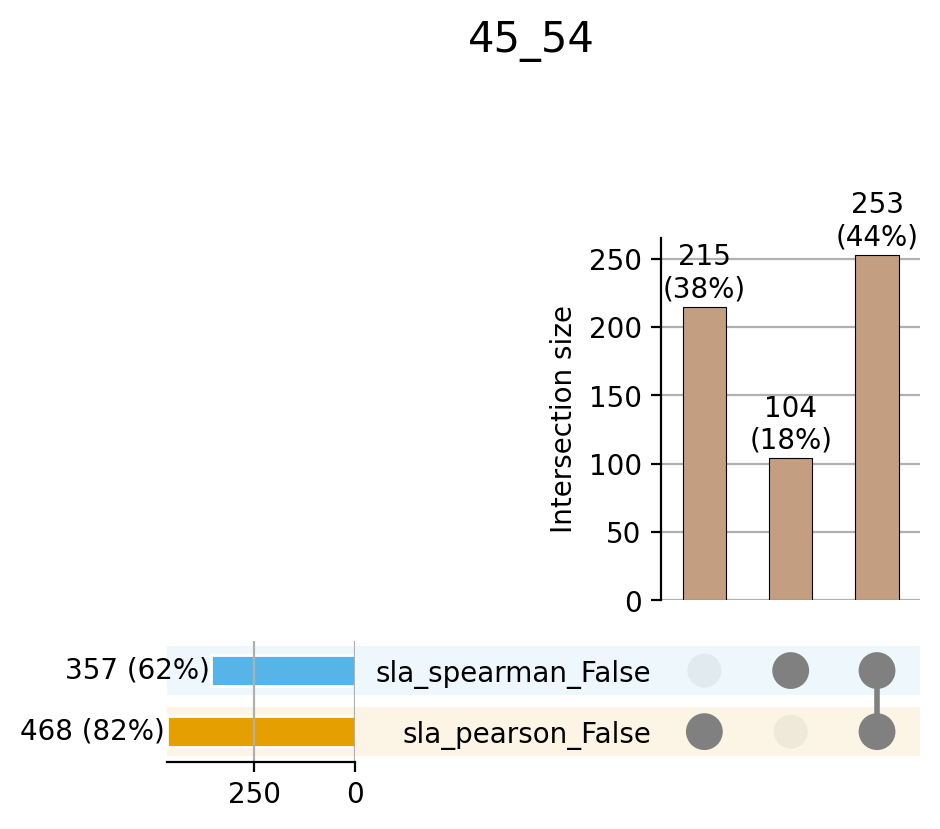

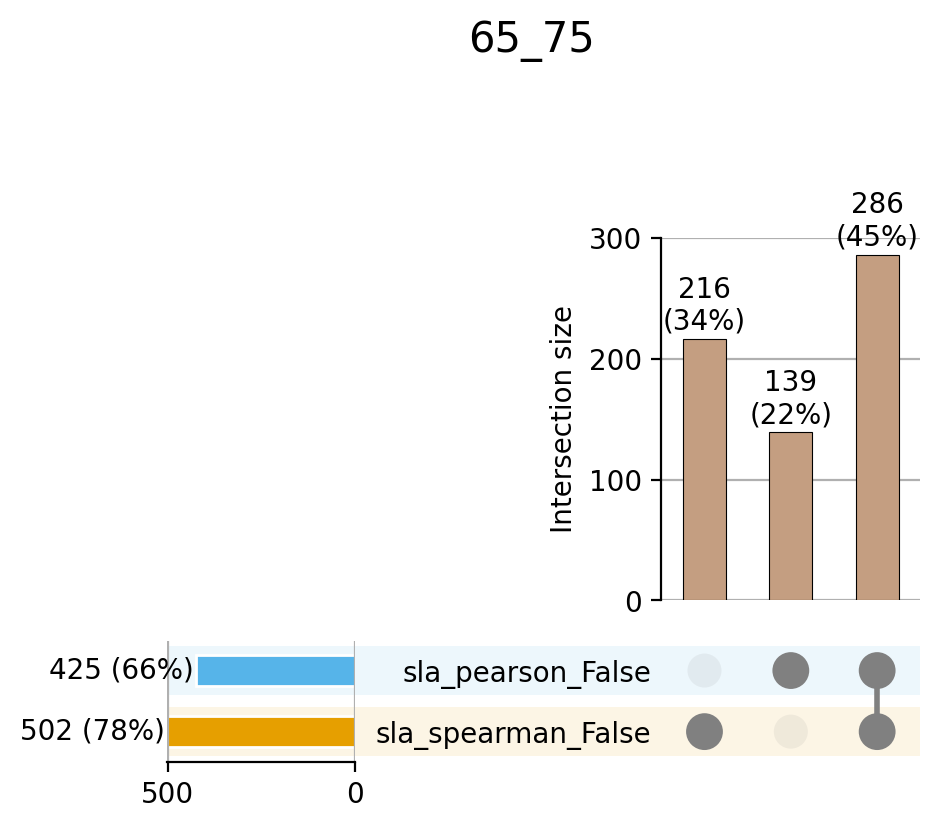

In [62]:
if True: # intersection of sig links across models: age specific 
    # for age_group in ['35_44', '45_54', '55_64', '65_75']:
    for age_group in ['45_54','65_75']:
        sig_results_a = sig_results[sig_results.age_group==age_group]
        
        # plot intersection
        links_dict = sig_results_a.groupby('model').apply(lambda df: df['link'].values).to_dict()
        interaction_df = create_interaction_df(links_dict)
        fig = plot_interactions(interaction_df, min_subset_size=10, min_degree=1, sort_by='degree')
        fig.suptitle(age_group, fontsize=15, y=1.2)

In [79]:
if False: #joint plot of different methods
    tag = 'mean'

    def plot_join(method1, method2):
        sns.jointplot(
            data = common_links_df, 
            x = f"{method1}-{tag}", 
            y = f"{method2}-{tag}", 
            hue="age_group",   # Color points by "True"/"False"
            # kind="kde",    # Contours with kde
            # fill=False,    # Fill contour lines
            marginal_kws=dict(common_norm=False, fill=True),  # Marginal distribution,
            alpha=.5
        )
        plt.xlabel(method1)
        plt.ylabel(method2)
        plt.suptitle(tag, fontsize=20, y=1.1)
    models = list(contrast_results_dict.keys())
    plot_join(models[0], models[1])
    # plot_join('sla_pearson', 'apr_pearson')

['65_75', '45_54', '55_64', '35_44']


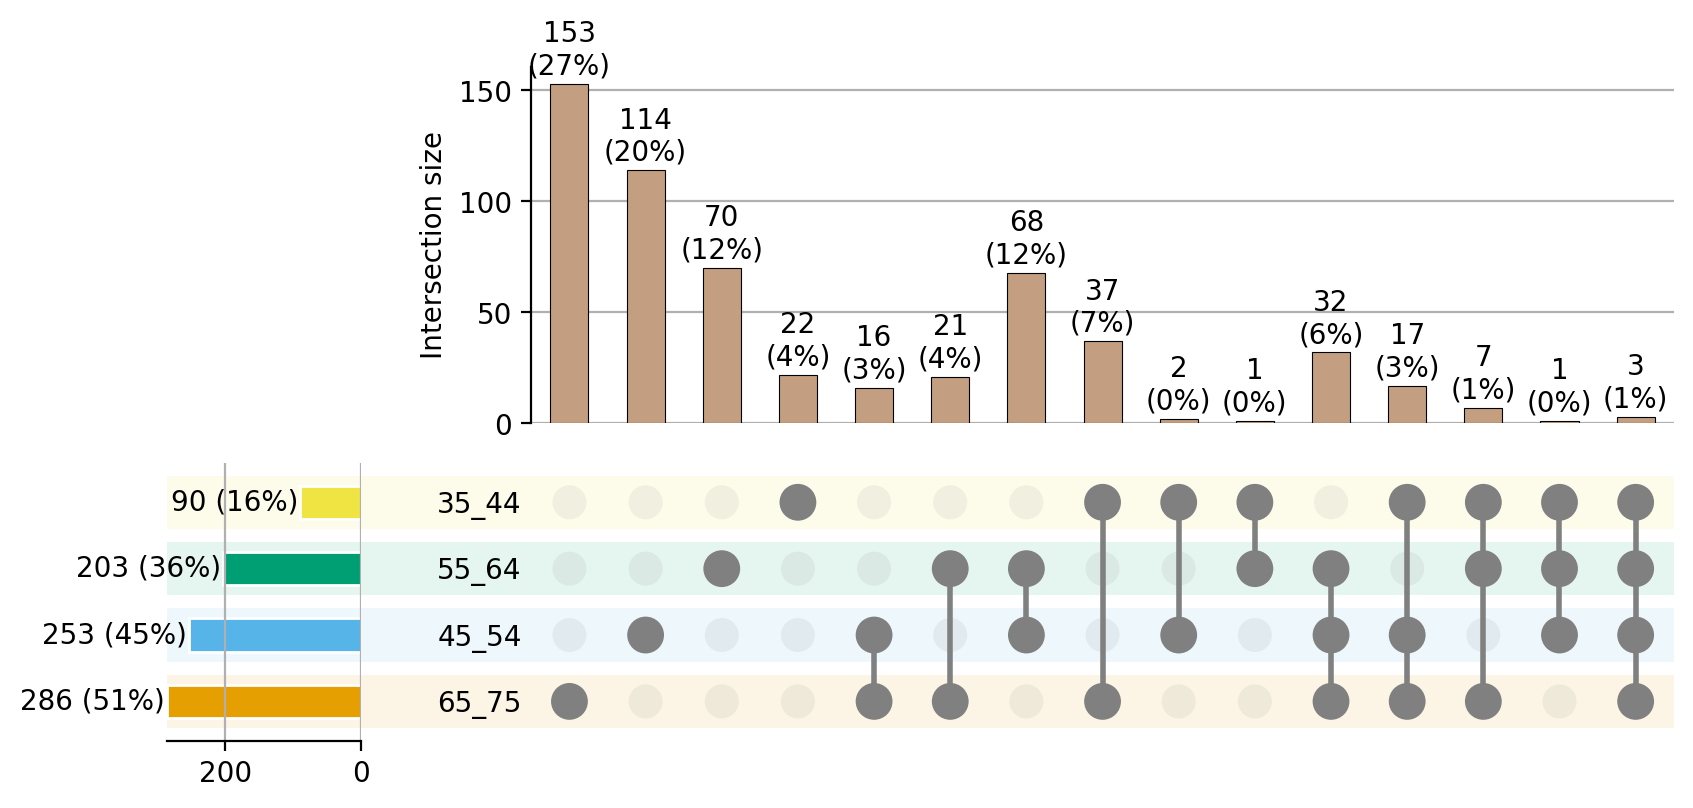

In [87]:
if True: # intersection of sig links for age groups
    df_sig = common_links_df
    groups = df_sig.groupby('age_group')
    
    interaction_df = create_interaction_df(groups.apply(lambda df: df['link'].values).to_dict())
    fig = plot_interactions(interaction_df, min_subset_size=1, min_degree=1, sort_by='degree')

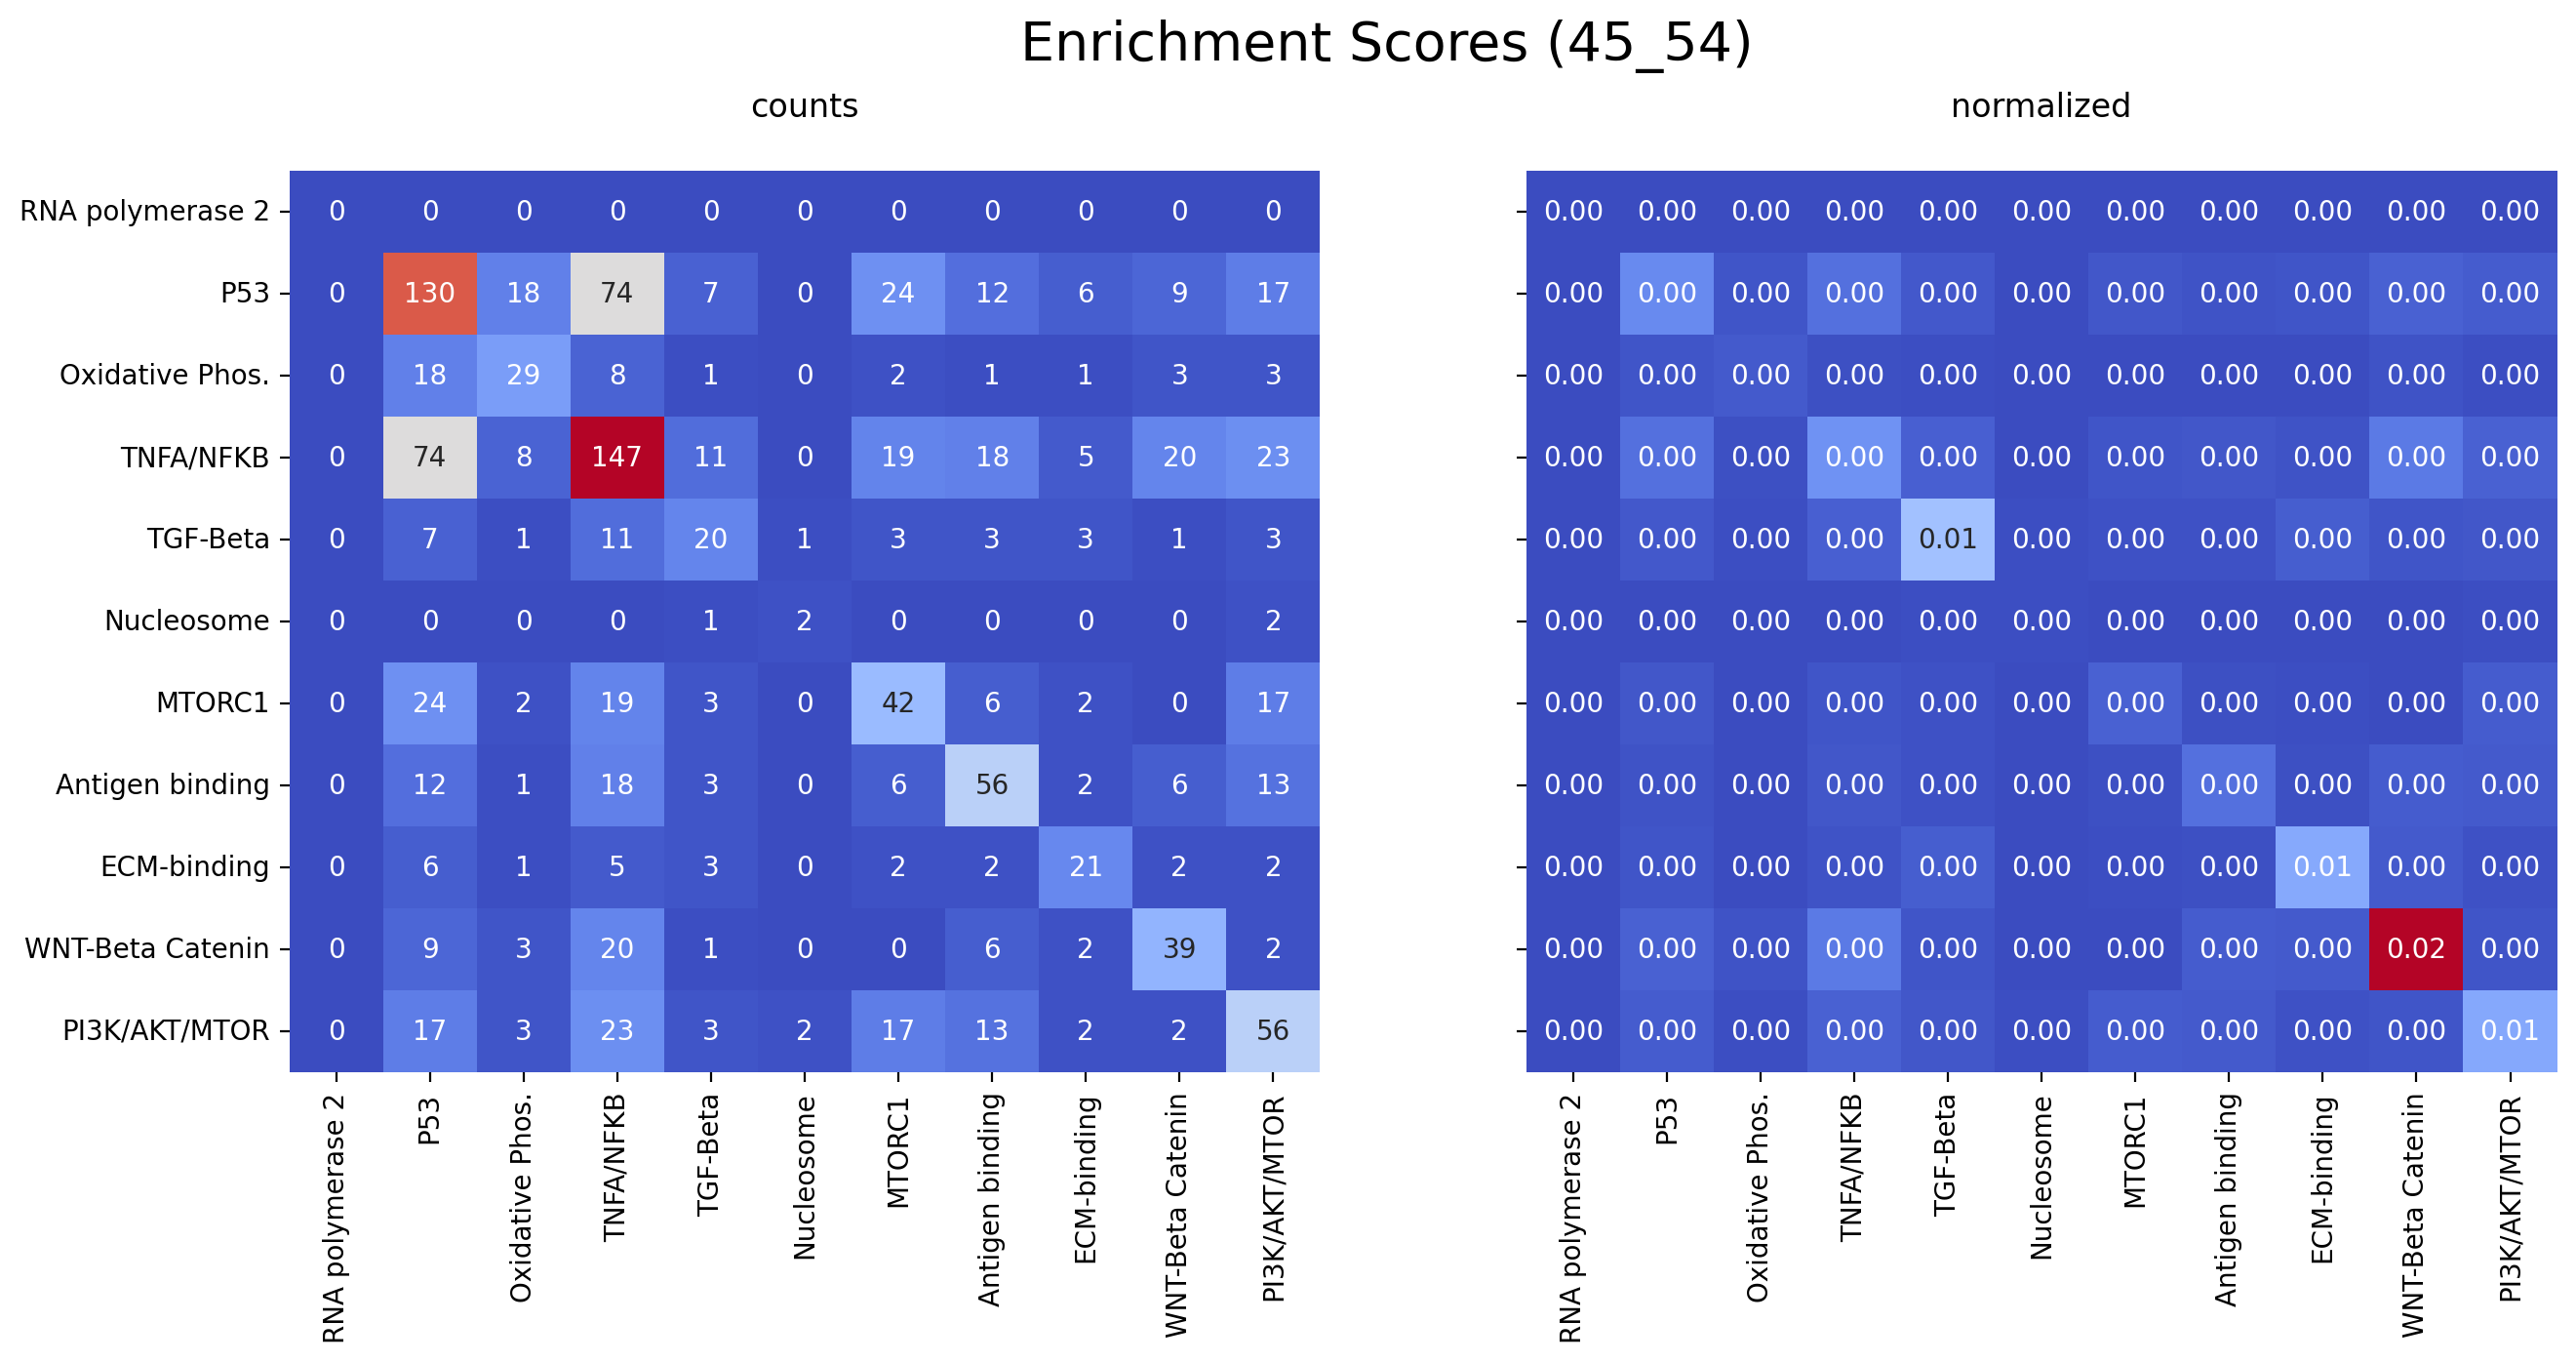

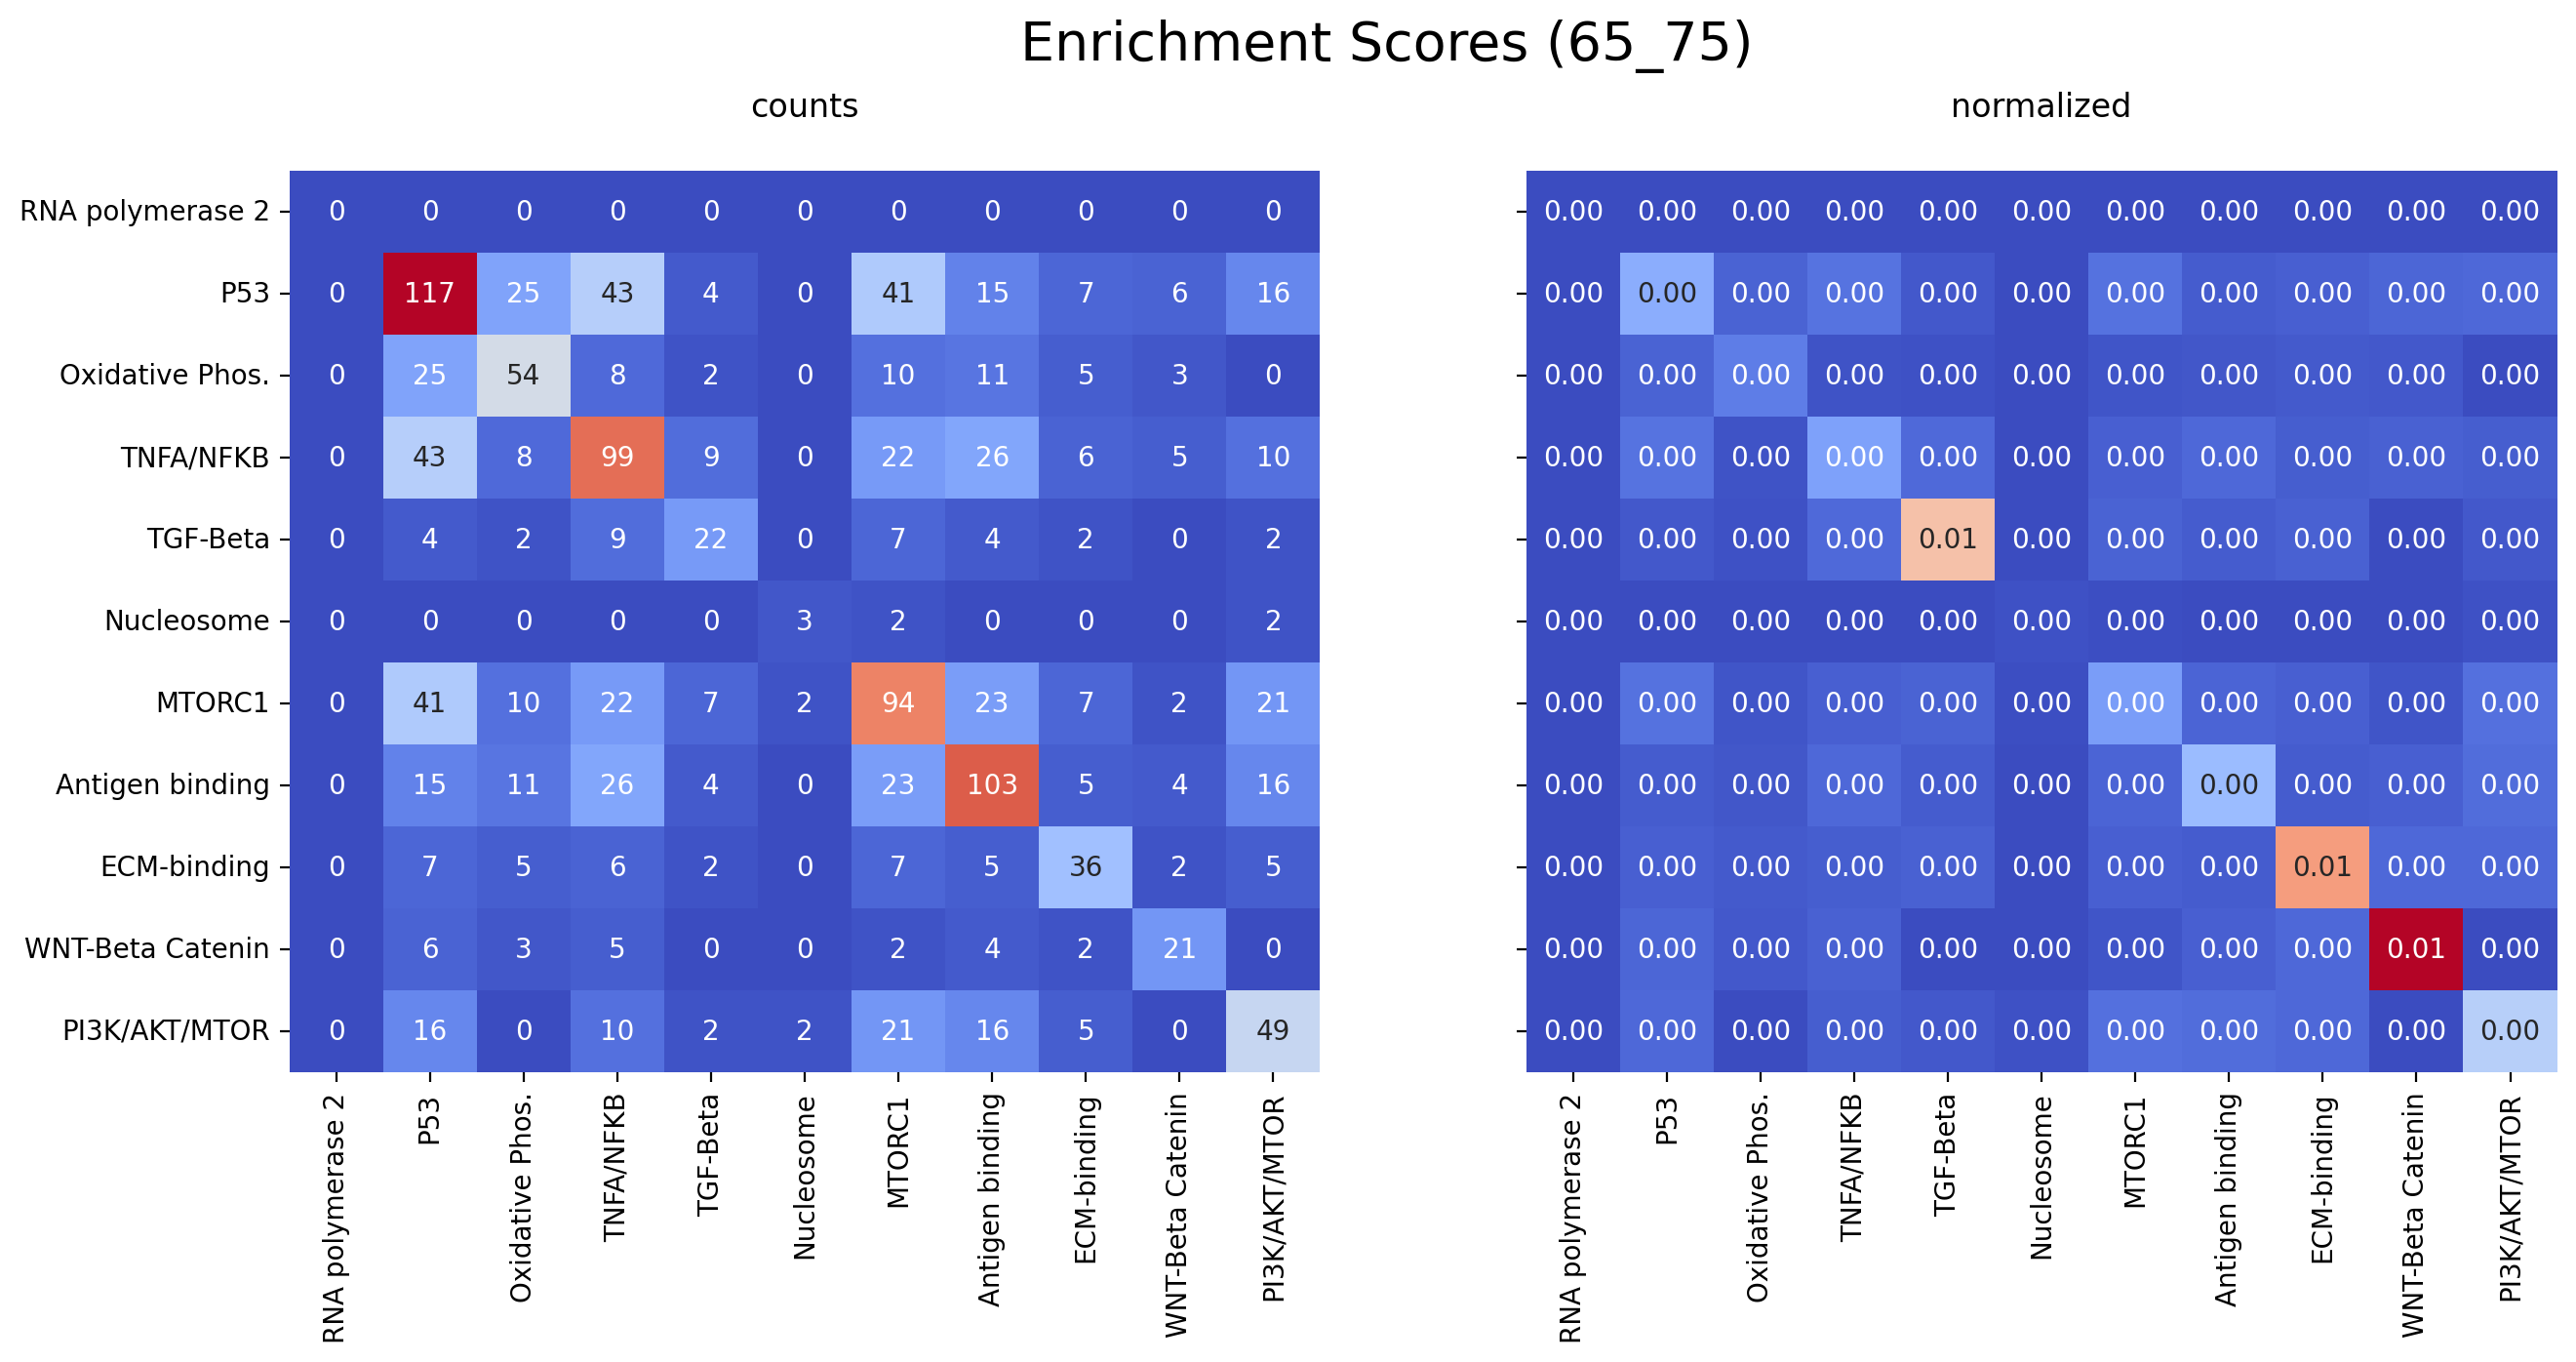

In [77]:
def extract_enrichment_scores(df):
    scores_mat = pd.DataFrame(np.zeros((n_pathway, n_pathway)), index=pathways, columns=pathways)
    i=0
    for g1, g2 in zip(df['g1'], df['g2']):
        pps = np.unique(pathway_df.loc[[g1, g2], 'pathway'].values)
        scores_mat.loc[pps,pps] = scores_mat.loc[pps,pps] + 1
    return scores_mat

if True: # enrichment score
    groups = common_links_df.groupby('age_group')

    pathways = list(set((pathway_df['pathway'].values)))
    n_pathway = len(pathways)

    # - determine the n possible links from each pathway combintation: to be used for normalization
    n_possible_links = pd.DataFrame(np.zeros((n_pathway, n_pathway)), index=pathways, columns=pathways)
    for p1 in pathways:
        for p2 in pathways:
            n_possible_links.loc[p1, p2] = len(genesets_dict[p1])*len(genesets_dict[p2])

    for age_group in ['45_54','65_75']:
        try:
            df_sig_a = groups.get_group(age_group)
        except:
            continue
        df_sig_a[['g1','g2']] = df_sig_a['link'].str.split('_', expand=True)
        df = df_sig_a
        # - get the enrichment scores 
        enrichment_scores = extract_enrichment_scores(df)
        enrichment_scores_n = enrichment_scores/n_possible_links

        # - plot    
        fig, axes = plt.subplots(1,2 , figsize=(15, 6), sharey=True, width_ratios=[1, 1])
        for i, (name, df) in enumerate(zip(['counts', 'normalized'], [enrichment_scores, enrichment_scores_n])):
            ax = axes[i]
            if name == 'normalized':
                fmt = '.02f'
            else:
                fmt = '.0f'
            sns.heatmap(df, annot=True, cmap='coolwarm', cbar=None,  ax=ax, fmt=fmt)
            ax.set_title(f'{name}', pad=20)
            ax.set_xlabel('')
            ax.set_ylabel('')
        fig.suptitle(f'Enrichment Scores ({age_group})', fontsize=20, y=1.01)

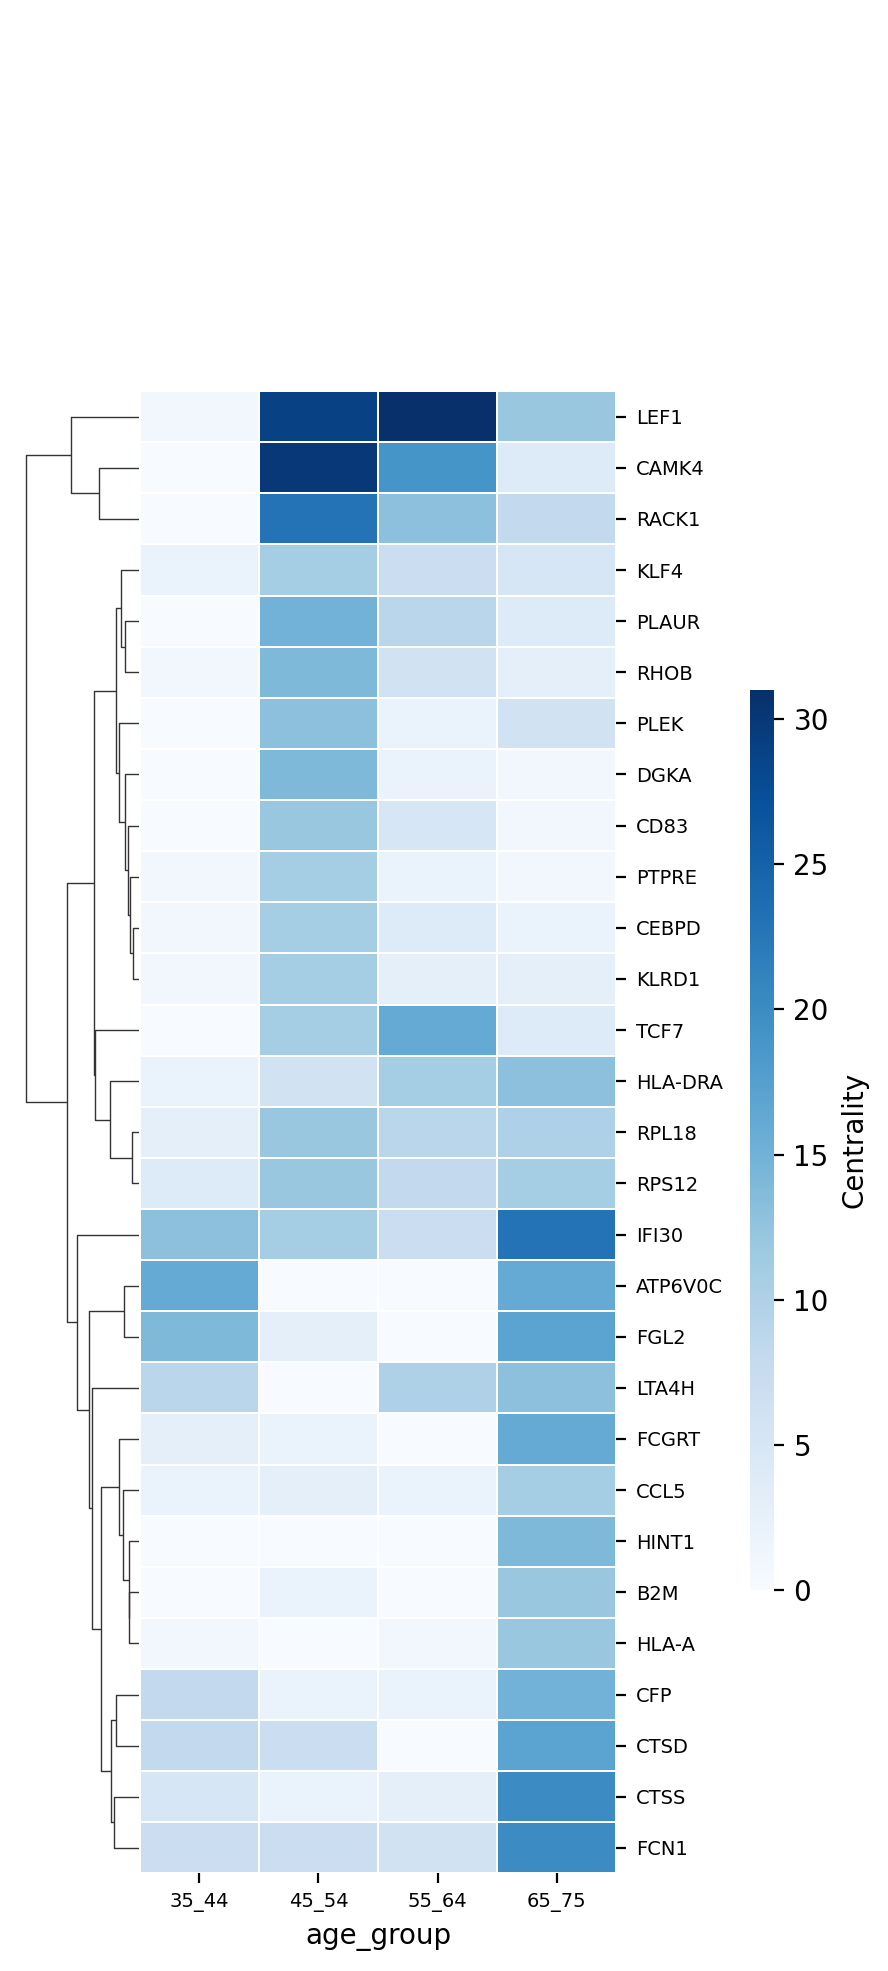

In [74]:
# - centrality degree dotplot, all ages, genes with degree > 10 in the target groups

if True: # plot_centrality_cluster()
    degree_t = 10

    groups = common_links_df.groupby('age_group')
    figsize=(4,10)
    target_groups=['45_54','65_75']

    # - heatmap
    def link_to_centrality(df):
        df['weight'] = 1
        gg_mat = link_to_matrix(df)
        degree = gg_mat.sum(axis=1)  
        return degree
    centrality_df = groups.apply(link_to_centrality).reset_index(level=0, name='degree').pivot(columns='age_group', values='degree').fillna(0)

    # filter 
    centrality_df = centrality_df[(centrality_df>degree_t)[target_groups].any(axis=1)]

    # plot
    g = sns.clustermap(centrality_df, cmap="Blues", row_cluster=True, col_cluster=False, 
                    figsize=figsize, linewidths=0.01, xticklabels=True, yticklabels=True, 
                    cbar_pos=(0.95, 0.2, 0.03, 0.45))
    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=7)  
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), fontsize=7)  
    g.cax.set_ylabel('Centrality')
    plt.tight_layout()

In [110]:
if False: #heatmap  pathway association
    # - pathway association of sig links for age 65_75
    df_sig_a = groups.get_group('65_75')
    df_sig_a['weight'] = -np.log10(df_sig_a['pvalue'])

    g_g_mat = link_to_matrix(df_sig_a)
    heatmap_pathways(g_g_mat, pathway_df)

In [111]:
# contrast_results_dict['links_pvalues_vs_34_apr_spearman_bootstrapped_denoised']

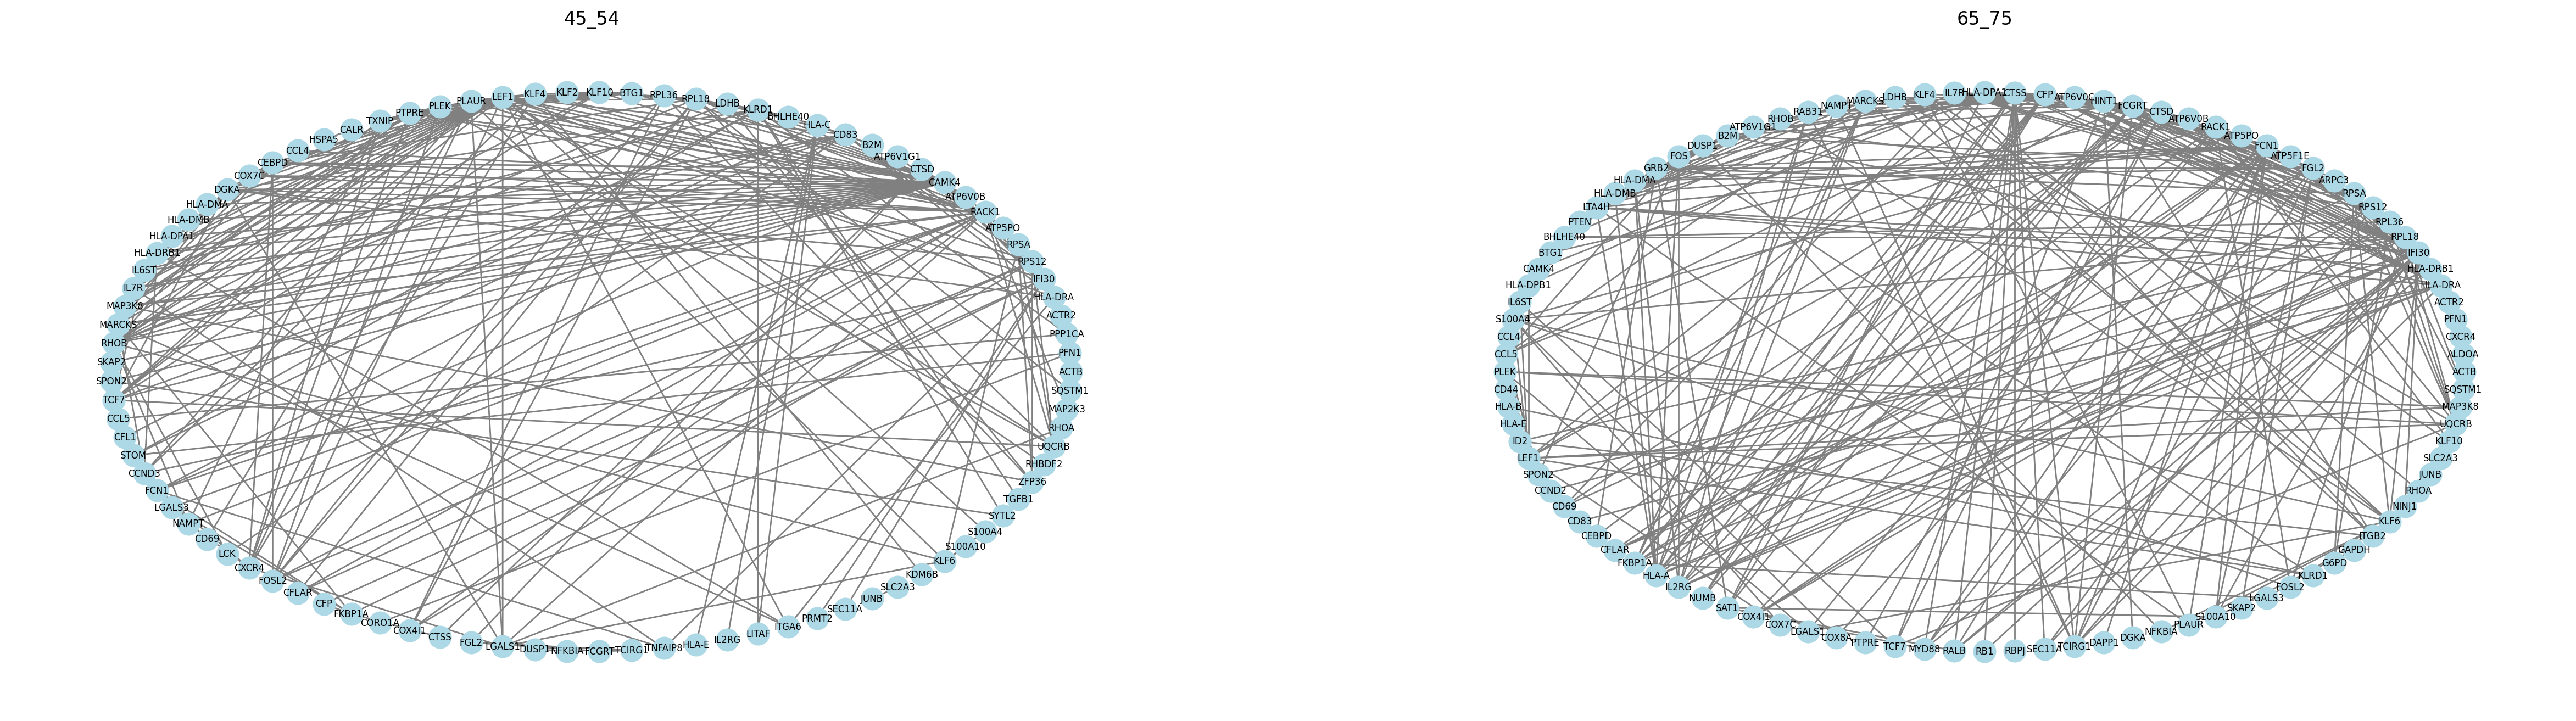

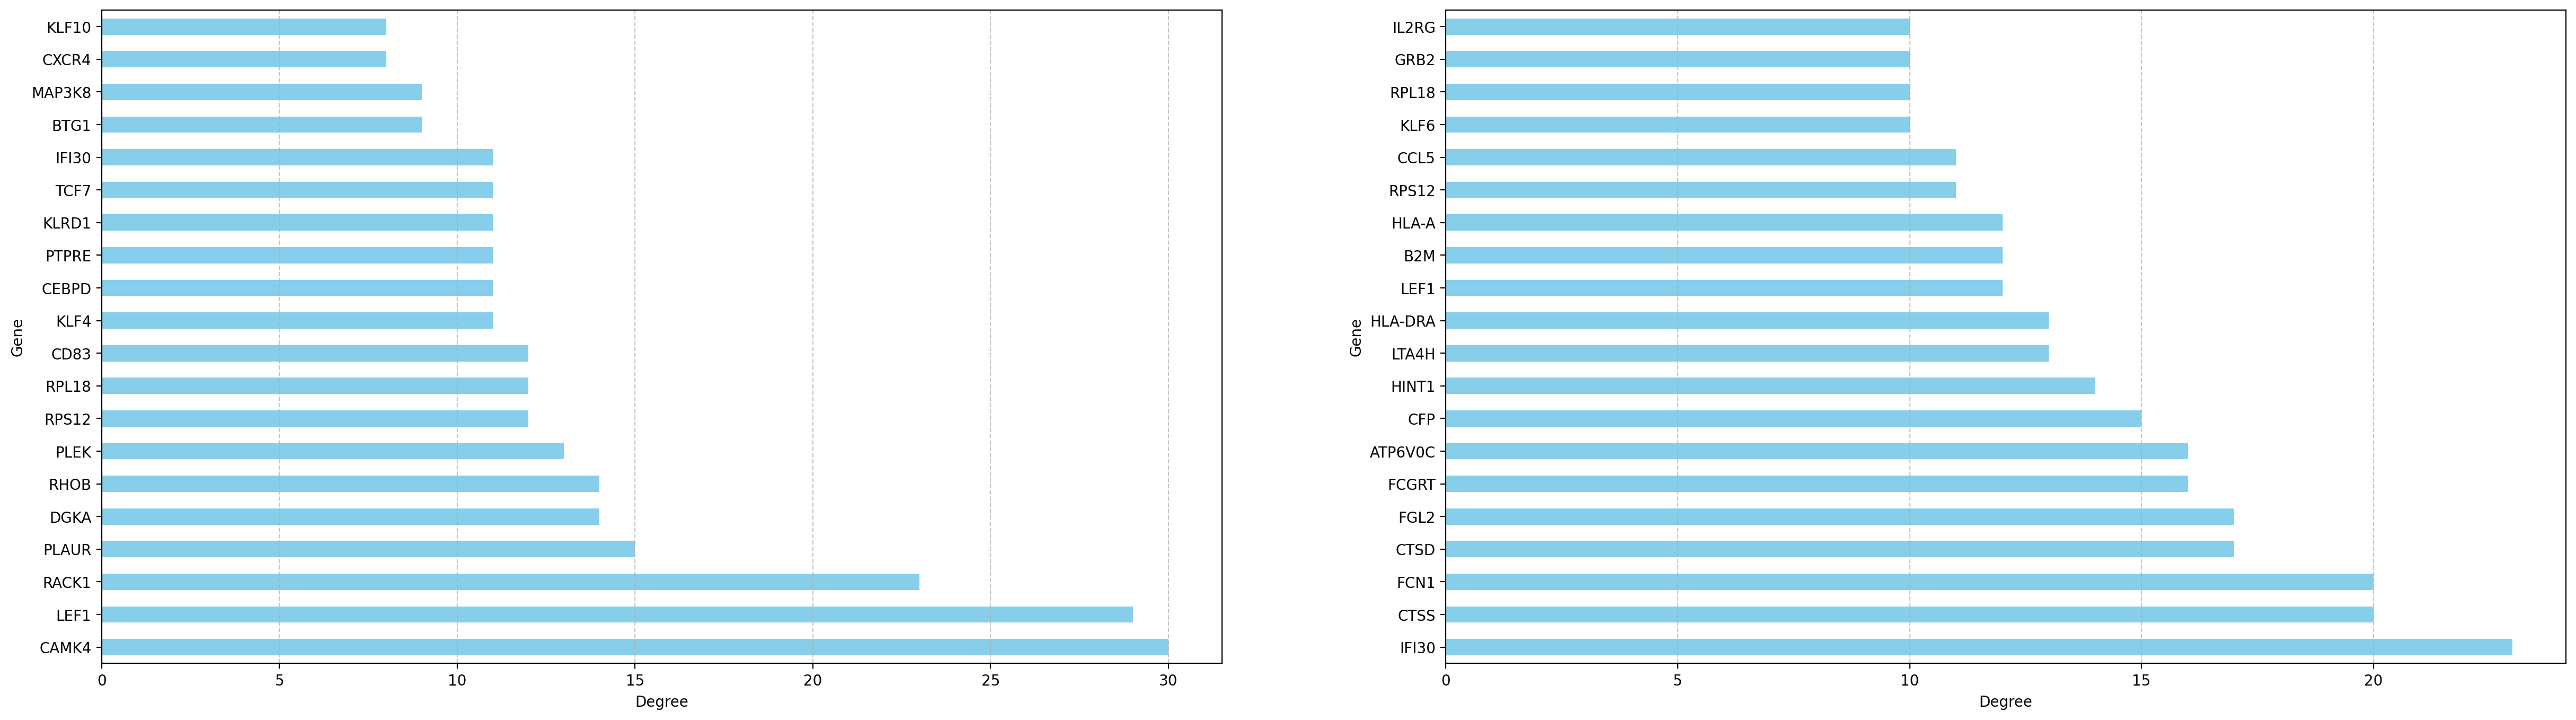

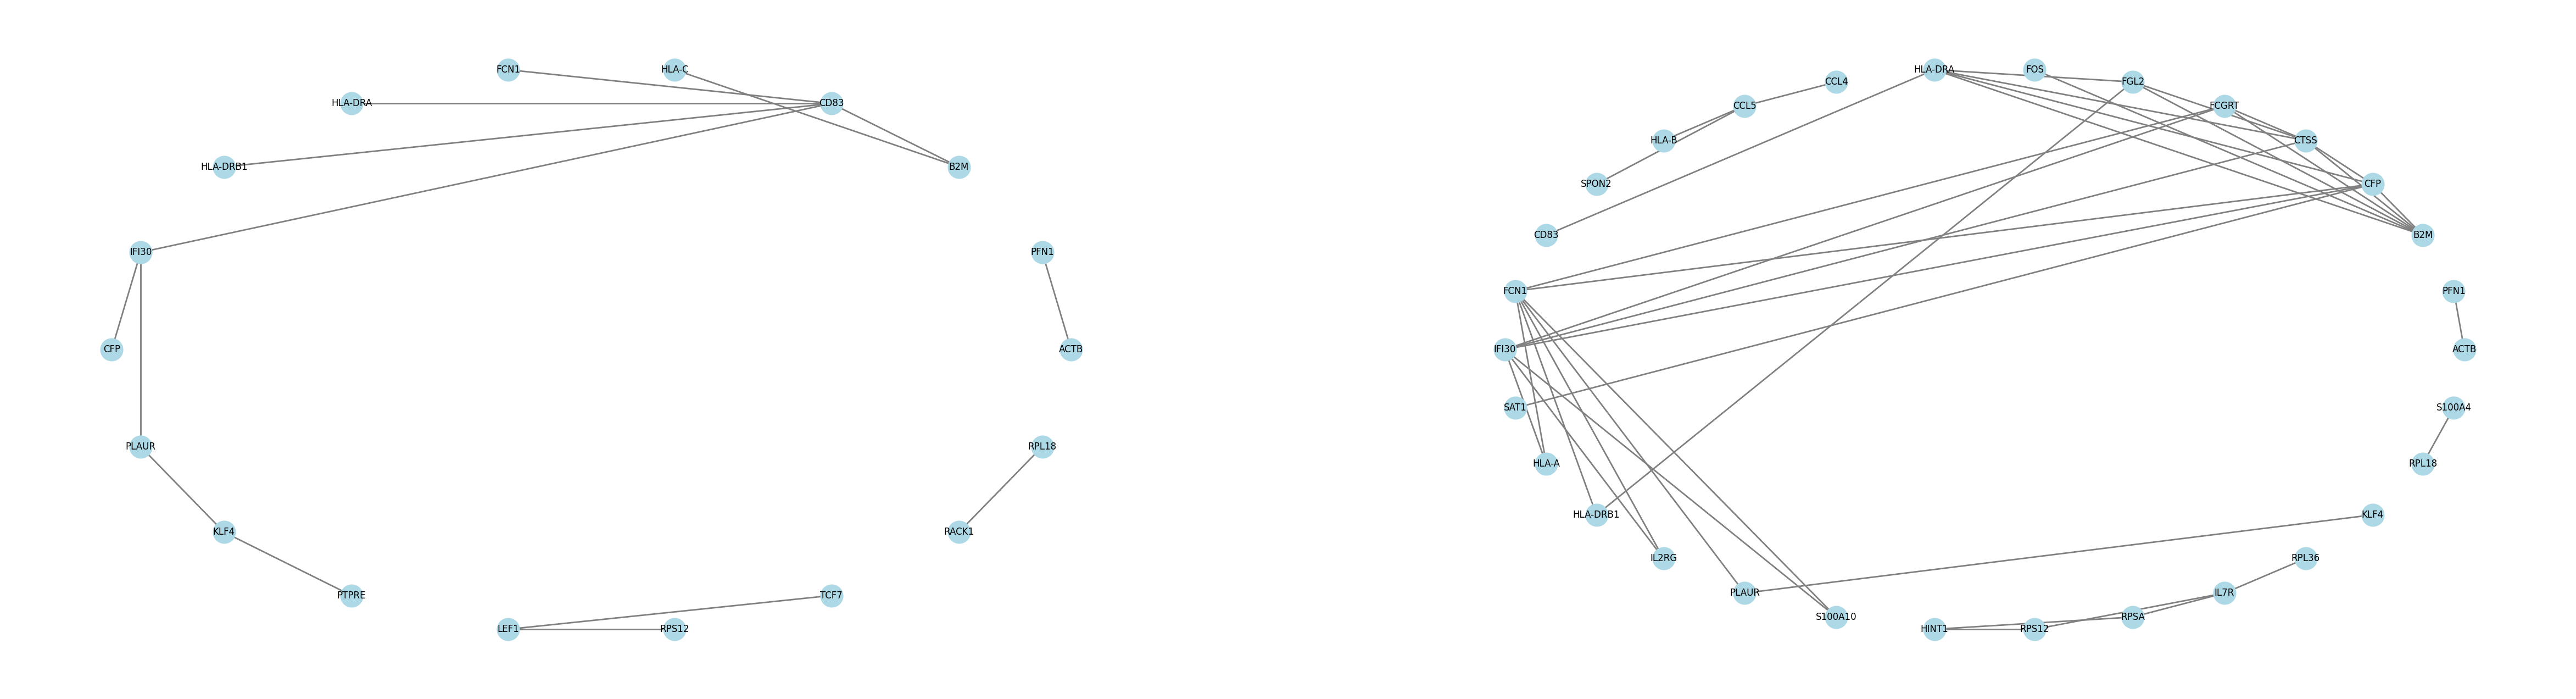

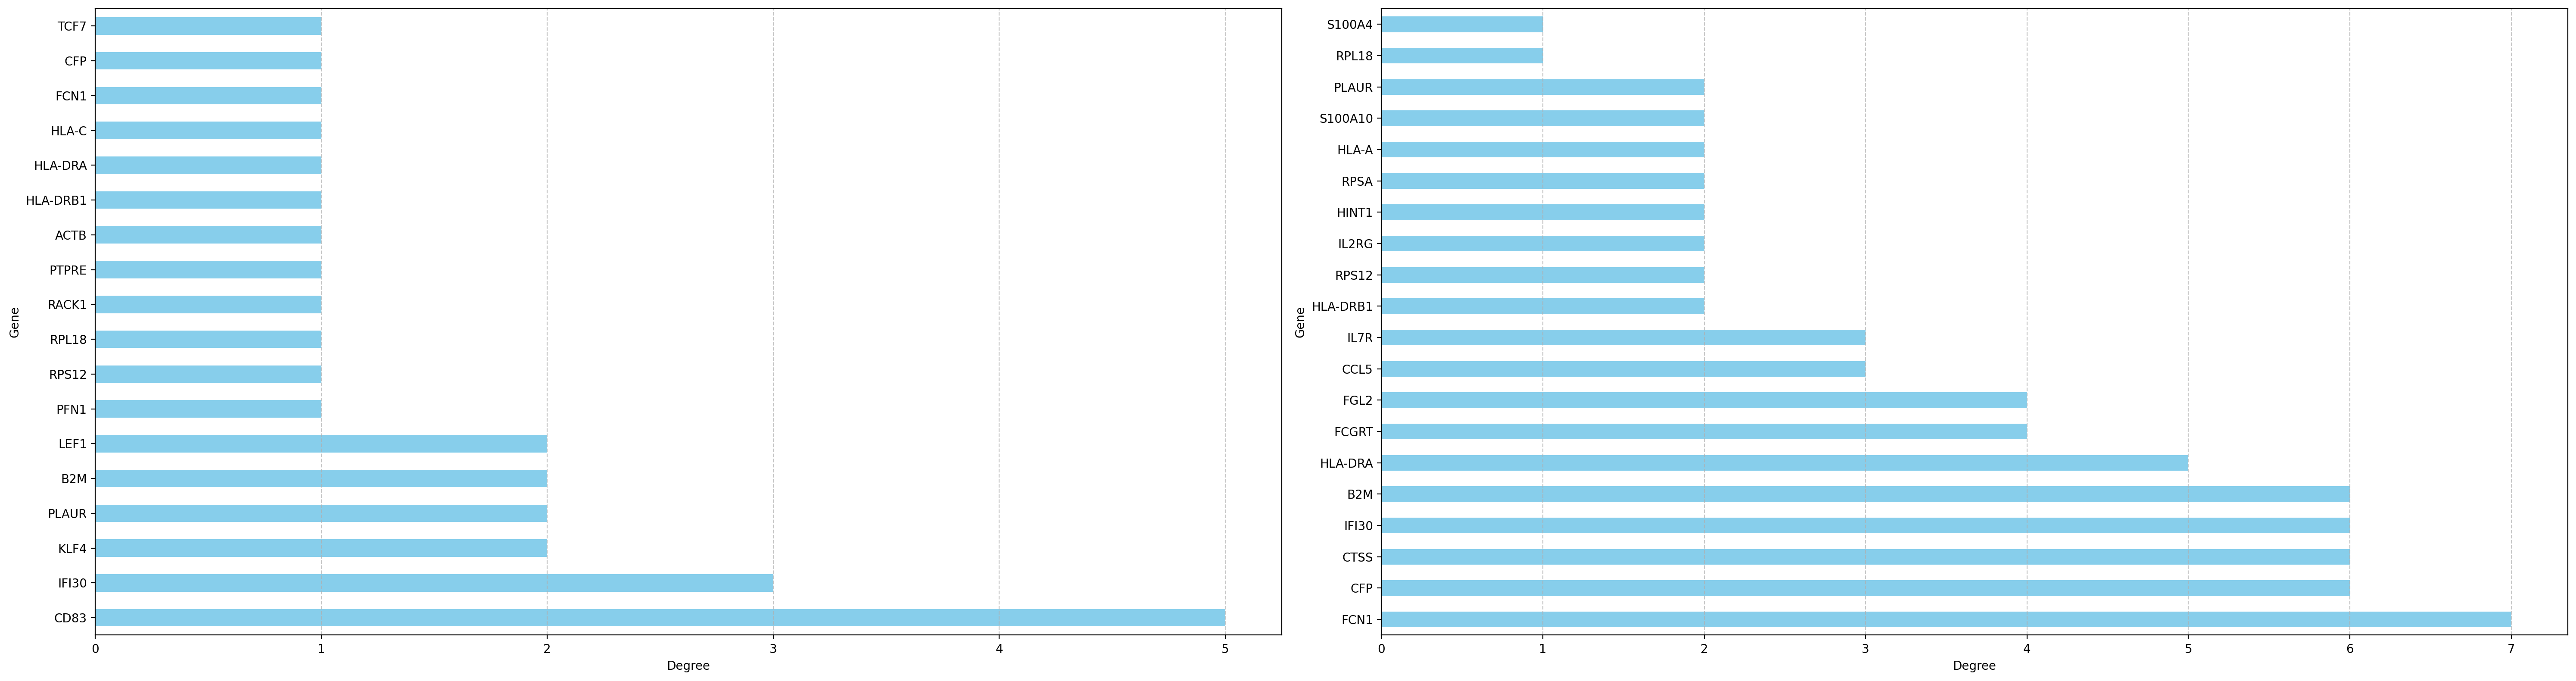

In [83]:
if True: # age group specific G plots and top degree fo 
    groups = common_links_df.groupby('age_group')
    age_groups_to_show =  ['45_54', '65_75']

    _, axes = plt.subplots(1, len(age_groups_to_show), figsize=(15*len(age_groups_to_show), 8))
    _, axes_ = plt.subplots(1, len(age_groups_to_show), figsize=(15*len(age_groups_to_show), 8))
    _, axes__ = plt.subplots(1, len(age_groups_to_show), figsize=(15*len(age_groups_to_show), 8))
    _, axes___ = plt.subplots(1, len(age_groups_to_show), figsize=(15*len(age_groups_to_show), 8))

    i_plot = 0 
    for age_group in age_groups_to_show:
        try:
            ax = axes[i_plot]
        except:
            ax = axes
        if age_group == '34-':
            continue
        # - plot all edges in G plot
        links_a = groups.get_group(age_group)
        G_plot(links_a, ax=axes[i_plot])
        ax.set_title(f'{age_group}') 

        # # - plot centrality
        links_a['weight'] = 1
        gg_mat = link_to_matrix(links_a)
        centrality_a = gg_mat.sum().sort_values(ascending=False)[:20]
        Exp_analysis.plot_centrality_barh(centrality_a, ax=axes_[i_plot])

        # - shortlist edges in G plot based on corr weights
        links_a_short = links_a[links_a['mean'].abs()>0.4]
        if len(links_a_short)<2: 
            continue
        G_plot(links_a_short, ax=axes__[i_plot])
        ax.set_title(f'{age_group}') 

        # - plot centrality for shortlist
        links_a_short['weight'] = 1
        gg_mat = link_to_matrix(links_a_short)
        centrality_a = gg_mat.sum().sort_values(ascending=False)[:20]
        Exp_analysis.plot_centrality_barh(centrality_a, ax=axes___[i_plot])

        i_plot+=1

        plt.tight_layout()